---
title: "1. EDA, data leakage y modelos"
---

# Proyecto Integrador — Heart Failure Prediction

## Nombres: Juan Camilo Oñoro Araujo - 200177329 y María Carolina Cantillo Orozco - 200179105
## Fecha: 30/09/2026

## MACHINE LEARNING

Notebook 1 — Etapa 1: Análisis exploratorio, preprocesamiento y detección de *data leakage*

# EDA

Qué se hace en esta etapa y por qué

Esta es la Etapa 1 del proyecto. Antes de entrenar un modelo hay que conocer los datos: qué variables hay, de qué tipo son, si faltan valores, si hay errores de registro y qué variables se relacionan con la enfermedad.

Se hace por dos razones. La primera es que un modelo solo es tan bueno como los datos con que se entrena: si no se detectan problemas como los ceros imposibles de cholesterol, el modelo aprende de información falsa. La segunda es que las decisiones de preprocesamiento (cómo llenar los faltantes, qué escalar y cómo codificar las categóricas) salen de lo que se observa aquí.

Parte 1. Importar librerías necesarias y configuraciones

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.1.0 | numpy 1.25.2 | seaborn 0.12.2


Estilo de gráficas

In [2]:
COLOR = {
    "principal":  "#2a78d6",   # azul: color de serie por defecto
    "secundario": "#eb6834",   # naranja: solo para destacar
    "texto":      "#0b0b0b",
    "texto_2":    "#52514e",
    "tenue":      "#898781",   # gris: categorías raras / outliers
    "rejilla":    "#e1e0d9",
    "eje":        "#c3c2b7",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Calibri", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.labelcolor": COLOR["texto_2"],
    "axes.edgecolor": COLOR["eje"],
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR["rejilla"],
    "grid.linewidth": 0.6,
    "xtick.color": COLOR["texto_2"],
    "ytick.color": COLOR["texto_2"],
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "text.color": COLOR["texto"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

# Colores y nombres de las clases de la variable objetivo
CLASE_COLOR = {0: COLOR["principal"], 1: COLOR["secundario"]}
CLASE_NOMBRE = {0: "Sin enfermedad", 1: "Con enfermedad"}

CMAP_DIV = LinearSegmentedColormap.from_list("azul_rojo", ["#104281", "#6da7ec", "#f0efec", "#ec835a", "#b2302f"])
CMAP_SEC = LinearSegmentedColormap.from_list("azul", ["#f7f9fc", "#9ec5f4", "#2a78d6", "#0d366b"])


def titulo_figura(fig, texto):
    fig.suptitle(texto, x=0.01, ha="left", fontsize=13, fontweight="semibold")


def fmt_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

Parte 2. Ruta de acceso al archivo y carga del dataset

In [3]:
# El notebook vive en notebooks/, los datos en data/ y las figuras en figuras/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FILE_PATH = ROOT / "data" / "heart.csv"
FIG_DIR = ROOT / "figuras"
FIG_DIR.mkdir(exist_ok=True)

assert FILE_PATH.exists(), f"No se encontró el archivo: {FILE_PATH.resolve()}"

t_inicio = time.time()
df = pd.read_csv(FILE_PATH)
print(f"Archivo  : {FILE_PATH.resolve()}")
print(f"Tamaño   : {FILE_PATH.stat().st_size / 1e3:.1f} KB en disco")
print(f"Filas    : {df.shape[0]:,} pacientes")
print(f"Columnas : {df.shape[1]}")
print(f"Memoria  : {df.memory_usage(deep=True).sum() / 1e3:.1f} KB")
print(f"Carga en {time.time() - t_inicio:.3f} s")

Archivo  : E:\Documents\MachineLearningUN\heart-disease-mlops\data\heart.csv
Tamaño   : 35.9 KB en disco
Filas    : 918 pacientes
Columnas : 12
Memoria  : 324.8 KB
Carga en 0.005 s


Parte 3. Diccionario de variables y siglas para el texto

| Variable | Tipo | Descripción |
|---|---|---|
| age | Numérica | Edad del paciente (años) |
| sex | Categórica | Sexo: M masculino, F femenino |
| chestpaintype | Categórica | Tipo de dolor de pecho: TA angina típica, ATA angina atípica, NAP dolor no anginoso, ASY asintomático |
| restingbp | Numérica | Presión arterial en reposo (mm Hg) |
| cholesterol | Numérica | Colesterol sérico (mg/dl) |
| fastingbs | Binaria | Glucosa en ayunas: 1 si > 120 mg/dl, 0 en otro caso |
| restingecg | Categórica | Electrocardiograma en reposo: Normal, ST (anomalía de onda ST-T), LVH (hipertrofia ventricular izquierda) |
| maxhr | Numérica | Frecuencia cardíaca máxima alcanzada (60–202) |
| exerciseangina | Categórica | Angina inducida por ejercicio: Y sí, N no |
| oldpeak | Numérica | Depresión del segmento ST inducida por ejercicio (mm) |
| st_slope | Categórica | Pendiente del segmento ST en el pico del ejercicio: Up, Flat, Down |
| heartdisease | Objetivo | 1 enfermedad cardíaca, 0 normal |

fastingbs viene codificada como 0 o 1, así que en el EDA se analiza con las categóricas.

In [4]:
TARGET = "HeartDisease"
NUM_VARS = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
CAT_VARS = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

assert set(NUM_VARS + CAT_VARS + [TARGET]) == set(df.columns)
print(f"Numéricas   ({len(NUM_VARS)}): {NUM_VARS}")
print(f"Categóricas ({len(CAT_VARS)}): {CAT_VARS}")
print(f"Objetivo       : {TARGET}")

Numéricas   (5): ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categóricas (6): ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Objetivo       : HeartDisease


Parte 4. info() y tipos de datos

In [5]:
df.info()

tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "ejemplo": df.iloc[0],
    "rol": ["objetivo" if c == TARGET else "numérica" if c in NUM_VARS else "categórica" for c in df.columns],
})
display(tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,dtype,n_unicos,ejemplo,rol
Age,int64,50,40,numérica
Sex,object,2,M,categórica
ChestPainType,object,4,ATA,categórica
RestingBP,int64,67,140,numérica
Cholesterol,int64,222,289,numérica
FastingBS,int64,2,0,categórica
RestingECG,object,3,Normal,categórica
MaxHR,int64,119,172,numérica
ExerciseAngina,object,2,N,categórica
Oldpeak,float64,53,0.0000,numérica


El dataset tiene 918 pacientes y 12 columnas: 5 numéricas, 6 categóricas (contando fastingbs) y la variable objetivo. Las categóricas vienen como texto (object), así que habrá que codificarlas (One-Hot) antes de entrenar: MinMaxScaler y SVC no aceptan texto. La columna objetivo se llama heartdisease

Parte 5. Nulos explícitos y filas duplicadas

In [6]:
nulos = pd.DataFrame({"n_nulos": df.isna().sum(), "pct_nulos": df.isna().mean() * 100})
display(nulos.T)
print(f"Total de nulos explícitos: {df.isna().sum().sum()}")
print(f"Filas duplicadas         : {df.duplicated().sum()}")
print(f"Duplicados sin el target : {df.drop(columns=TARGET).duplicated().sum()}")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
n_nulos,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
pct_nulos,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Total de nulos explícitos: 0
Filas duplicadas         : 0
Duplicados sin el target : 0


info() reporta 918 valores no nulos en todas las columnas y no hay filas duplicadas. A primera vista el dataset está completo, pero la Parte 6 muestra que sí faltan datos: están codificados como 0 cuando es un valor imposible

Parte 6. Nulos ocultos: valores imposibles

Que no haya NaN no quiere decir que no falten datos. Un colesterol sérico o una presión arterial en reposo de 0 son fisiológicamente imposibles en un paciente vivo, así que corresponden a mediciones no registradas. En cambio, oldpeak = 0 es válido (no hay depresión del ST) y sus valores negativos también (elevación del ST).

In [7]:
CEROS_IMPOSIBLES = ["RestingBP", "Cholesterol"]      # 0 no es un valor clínico posible

filas = []
for col in NUM_VARS:
    s = df[col]
    filas.append({
        "variable": col,
        "min": s.min(), "max": s.max(),
        "n_ceros": int((s == 0).sum()),
        "pct_ceros": (s == 0).mean() * 100,
        "n_negativos": int((s < 0).sum()),
        "¿el 0 es posible?": "No → nulo oculto" if col in CEROS_IMPOSIBLES else "Sí",
    })
display(pd.DataFrame(filas).set_index("variable").style.format({"pct_ceros": "{:.2f} %", "min": "{:g}", "max": "{:g}"}))

# Copia para el EDA con los ceros imposibles marcados como faltantes.
# El dataset original (df) no se modifica: la imputación se hará dentro del Pipeline (sin fuga).
df_eda = df.copy()
df_eda[CEROS_IMPOSIBLES] = df_eda[CEROS_IMPOSIBLES].replace(0, np.nan)

print("Nulos en la copia del EDA:")
display(df_eda[CEROS_IMPOSIBLES].isna().agg(["sum", "mean"]).T.rename(columns={"sum": "n_nulos", "mean": "proporcion"}))

,min,max,n_ceros,pct_ceros,n_negativos,¿el 0 es posible?
variable,,,,,,
Age,28,77,0,0.00 %,0,Sí
RestingBP,0,200,1,0.11 %,0,No → nulo oculto
Cholesterol,0,603,172,18.74 %,0,No → nulo oculto
MaxHR,60,202,0,0.00 %,0,Sí
Oldpeak,-2.6,6.2,368,40.09 %,13,Sí


Nulos en la copia del EDA:


,n_nulos,proporcion
RestingBP,1.0000,0.0011
Cholesterol,172.0000,0.1874


Lo que sale:

1. cholesterol tiene 172 ceros (18.7 % de los pacientes). Es el problema de calidad más importante del dataset. El valor mínimo real, sin contar los ceros, es 85 mg/dl.
2. restingbp tiene un solo cero (0.1 %). Es un error de registro aislado.
3. oldpeak tiene 368 ceros y 13 valores negativos. Ambos son válidos: 0 significa que no hubo depresión del ST, y un valor negativo, que hubo elevación.

En la copia df_eda estos ceros se convierten en NaN para que no distorsionen las estadísticas. El df original no se toca, porque la imputación se hará dentro del Pipeline usando solo el conjunto de entrenamiento, para no introducir un data leakeage

A. Variables numéricas

Parte 7. Estadísticos descriptivos e IQR (con los ceros imposibles como faltantes)

In [8]:
def resumen_numerico(data, columnas):
    filas = []
    for col in columnas:
        s = data[col].dropna().astype("float64")
        q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
        filas.append({
            "variable": col, "n": len(s),
            "media": s.mean(), "mediana": q2, "desv_std": s.std(),
            "min": s.min(), "p25": q1, "p50": q2, "p75": q3, "max": s.max(),
            "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
            "n_outliers": n_out, "pct_outliers": n_out / len(s) * 100,
            "asimetria": s.skew(), "curtosis": s.kurt(),
        })
    return pd.DataFrame(filas).set_index("variable")

resumen_num = resumen_numerico(df_eda, NUM_VARS)
display(resumen_num.style.format("{:,.2f}"))

# Efecto de dejar los ceros como si fueran datos reales
comparacion = pd.DataFrame({
    "media_con_ceros": df[CEROS_IMPOSIBLES].mean(),
    "media_sin_ceros": df_eda[CEROS_IMPOSIBLES].mean(),
    "mediana_con_ceros": df[CEROS_IMPOSIBLES].median(),
    "mediana_sin_ceros": df_eda[CEROS_IMPOSIBLES].median(),
})
print("Efecto de los ceros imposibles en la media y la mediana:")
display(comparacion.style.format("{:,.1f}"))

,n,media,mediana,desv_std,min,p25,p50,p75,max,IQR,lim_inf,lim_sup,n_outliers,pct_outliers,asimetria,curtosis
variable,,,,,,,,,,,,,,,,
Age,918.00,53.51,54.00,9.43,28.00,47.00,54.00,60.00,77.00,13.00,27.50,79.50,0.00,0.00,-0.20,-0.39
RestingBP,917.00,132.54,130.00,18.00,80.00,120.00,130.00,140.00,200.00,20.00,90.00,170.00,27.00,2.94,0.61,0.79
Cholesterol,746.00,244.64,237.00,59.15,85.00,207.25,237.00,275.00,603.00,67.75,105.62,376.62,23.00,3.08,1.24,4.53
MaxHR,918.00,136.81,138.00,25.46,60.00,120.00,138.00,156.00,202.00,36.00,66.00,210.00,2.00,0.22,-0.14,-0.45
Oldpeak,918.00,0.89,0.60,1.07,-2.60,0.00,0.60,1.50,6.20,1.50,-2.25,3.75,16.00,1.74,1.02,1.20


Efecto de los ceros imposibles en la media y la mediana:


,media_con_ceros,media_sin_ceros,mediana_con_ceros,mediana_sin_ceros
RestingBP,132.4,132.5,130.0,130.0
Cholesterol,198.8,244.6,223.0,237.0


Si los ceros se dejaran como datos reales, la media de cholesterol bajaría de 244.6 a 198.8 mg/dl (−46 mg/dl) y la mediana de 237 a 223. El conjunto de datos parecería mucho más sano de lo que es. En restingbp el efecto de un solo cero es despreciable.

La edad va de 28 a 77 años (mediana 54). La presión en reposo tiene mediana 130 mm Hg. maxhr va de 60 a 202 latidos por minuto. oldpeak tiene mediana 0.6 y está concentrada cerca de 0. Conla mediana, el 50% de las personas registradas parecen tener problemas de presión arterial alta (lo normal es 120 en una persona sana)

Parte 8. Outliers (regla de 1.5 × IQR)

In [9]:
outliers = (resumen_num[["p25", "p75", "IQR", "lim_inf", "lim_sup", "min", "max", "n_outliers", "pct_outliers"]]
            .sort_values("pct_outliers", ascending=False))
display(outliers.style.format("{:,.2f}"))

# Detalle de los valores fuera de los límites
for col in NUM_VARS:
    lim_inf, lim_sup = resumen_num.loc[col, ["lim_inf", "lim_sup"]]
    s = df_eda[col].dropna()
    fuera = s[(s < lim_inf) | (s > lim_sup)]
    if len(fuera):
        print(f"{col:12s} ({len(fuera)} outliers): bajos = {sorted(fuera[fuera < lim_inf].unique())[:10]} | "
              f"altos = {sorted(fuera[fuera > lim_sup].unique())[-10:]}")

,p25,p75,IQR,lim_inf,lim_sup,min,max,n_outliers,pct_outliers
variable,,,,,,,,,
Cholesterol,207.25,275.00,67.75,105.62,376.62,85.00,603.00,23.00,3.08
RestingBP,120.00,140.00,20.00,90.00,170.00,80.00,200.00,27.00,2.94
Oldpeak,0.00,1.50,1.50,-2.25,3.75,-2.60,6.20,16.00,1.74
MaxHR,120.00,156.00,36.00,66.00,210.00,60.00,202.00,2.00,0.22
Age,47.00,60.00,13.00,27.50,79.50,28.00,77.00,0.00,0.00


RestingBP    (27 outliers): bajos = [80.0] | altos = [172.0, 174.0, 178.0, 180.0, 185.0, 190.0, 192.0, 200.0]
Cholesterol  (23 outliers): bajos = [85.0, 100.0] | altos = [412.0, 417.0, 458.0, 466.0, 468.0, 491.0, 518.0, 529.0, 564.0, 603.0]
MaxHR        (2 outliers): bajos = [60, 63] | altos = []
Oldpeak      (16 outliers): bajos = [-2.6] | altos = [3.8, 4.0, 4.2, 4.4, 5.0, 5.6, 6.2]


Hay pocos outliers: como máximo 3 % por variable. Todos son clínicamente plausibles:

1. restingbp: 27 outliers entre 172 y 200 mm Hg, que corresponden a hipertensión severa, y un 80 mm Hg.
2. cholesterol: 23 outliers. Los altos van de 412 a 603 mg/dl (hipercolesterolemia) y los bajos son 85 y 100.
3. oldpeak: 16 outliers. Los altos, de 3.8 a 6.2, indican isquemia marcada, y el bajo es −2.6.
4. maxhr: solo 2 valores bajos (60 y 63).

No se eliminan: son pacientes reales con valores extremos, justamente los que más interesan para detectar enfermedad. Con 918 filas, quitar outliers además costaría información.

Parte 9. Histogramas

El diagrama 6  muestra cholesterol con los ceros originales, para ver el tamaño del pico de faltantes.

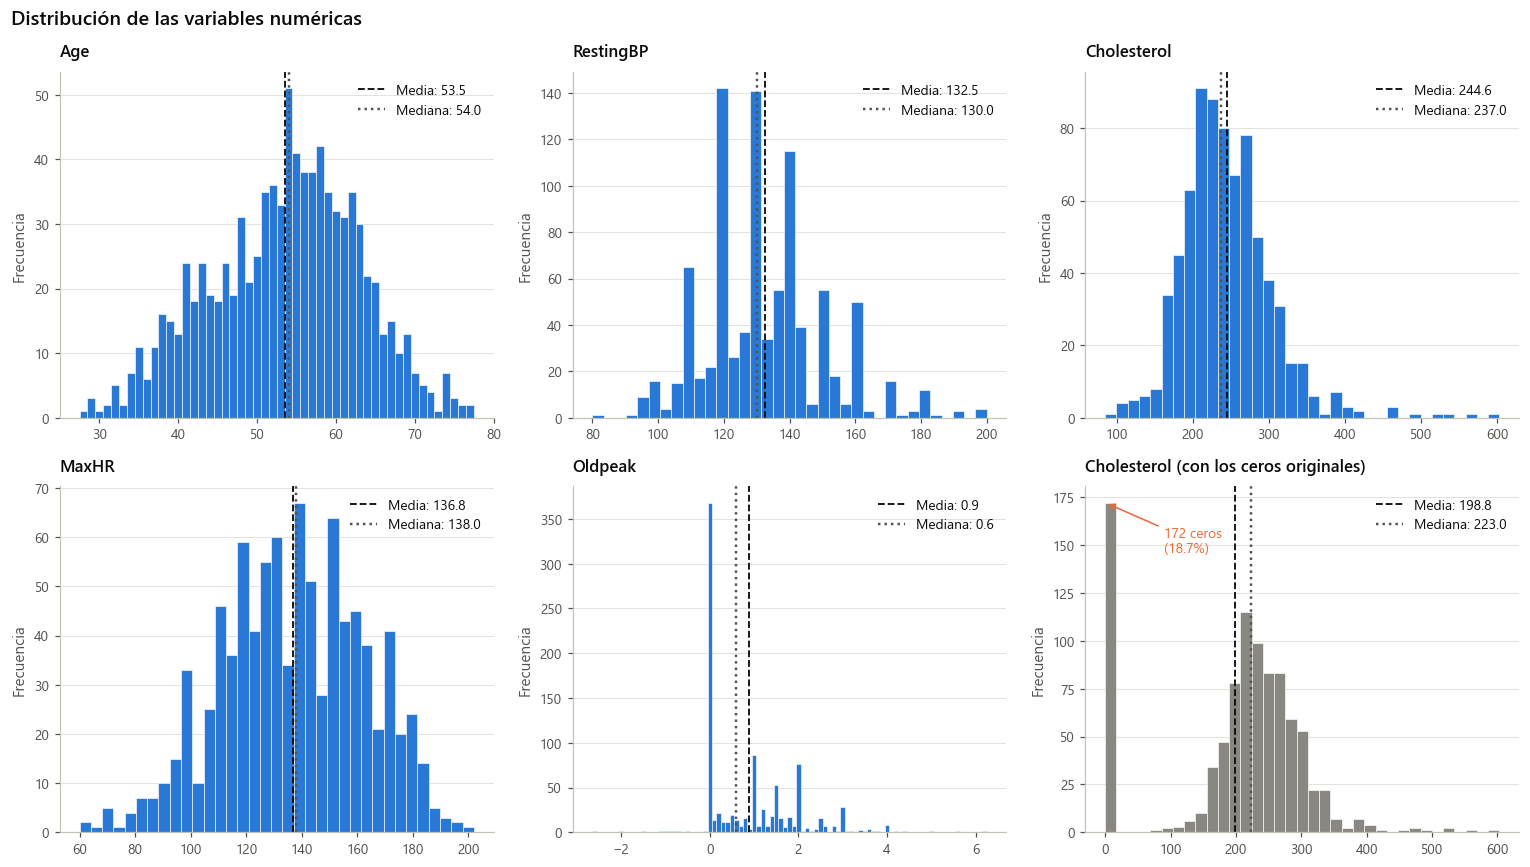

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
paneles = [(col, df_eda[col].dropna()) for col in NUM_VARS] + [("Cholesterol (con los ceros originales)", df["Cholesterol"])]

for ax, (nombre, s) in zip(axes.flat, paneles):
    unicos = np.unique(s)
    if len(unicos) <= 60:                      # variable discreta: una barra por valor
        paso = np.diff(unicos).min()
        bins = np.arange(unicos[0] - paso / 2, unicos[-1] + paso, paso)
    else:
        bins = 35
    es_original = "originales" in nombre
    ax.hist(s, bins=bins, color=COLOR["tenue"] if es_original else COLOR["principal"],
            edgecolor="white", linewidth=0.4)
    ax.axvline(s.mean(), color=COLOR["texto"], linestyle="--", linewidth=1.2, label=f"Media: {s.mean():,.1f}")
    ax.axvline(s.median(), color=COLOR["texto_2"], linestyle=":", linewidth=1.6, label=f"Mediana: {s.median():,.1f}")
    if es_original:
        n0 = int((s == 0).sum())
        ax.annotate(f"{n0} ceros\n({n0 / len(s):.1%})", xy=(0, n0), xytext=(90, n0 * 0.85),
                    color=COLOR["secundario"], fontsize=9, arrowprops=dict(arrowstyle="->", color=COLOR["secundario"]))
    ax.set_title(nombre)
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right")

titulo_figura(fig, "Distribución de las variables numéricas")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_histogramas.png")
plt.show()

1. age y maxhr tienen forma casi simétrica, con la media y la mediana prácticamente iguales.
2. restingbp muestra picos en 120, 130, 140, 150 y 160: el personal médico redondea las lecturas al valor más cercano, especialmente cuando es tomada con un instrumento de aguja, no digital. Se podrían establecer hiótesis si se conociera la fecha del dataset o los recursos económicos donde se tomaron las muestras
3. cholesterol, sin los ceros, tiene asimetría a la derecha, con una cola hasta 603.
4. oldpeak tiene un pico enorme en 0 (40 % de los pacientes) y una cola larga a la derecha.
5. El sexto diargama muestra lo grave que es el problema de cholesterol: la barra de los ceros es la más alta de toda la distribución, separada del resto por un hueco entre 0 y 85.

Parte 10. Box plots

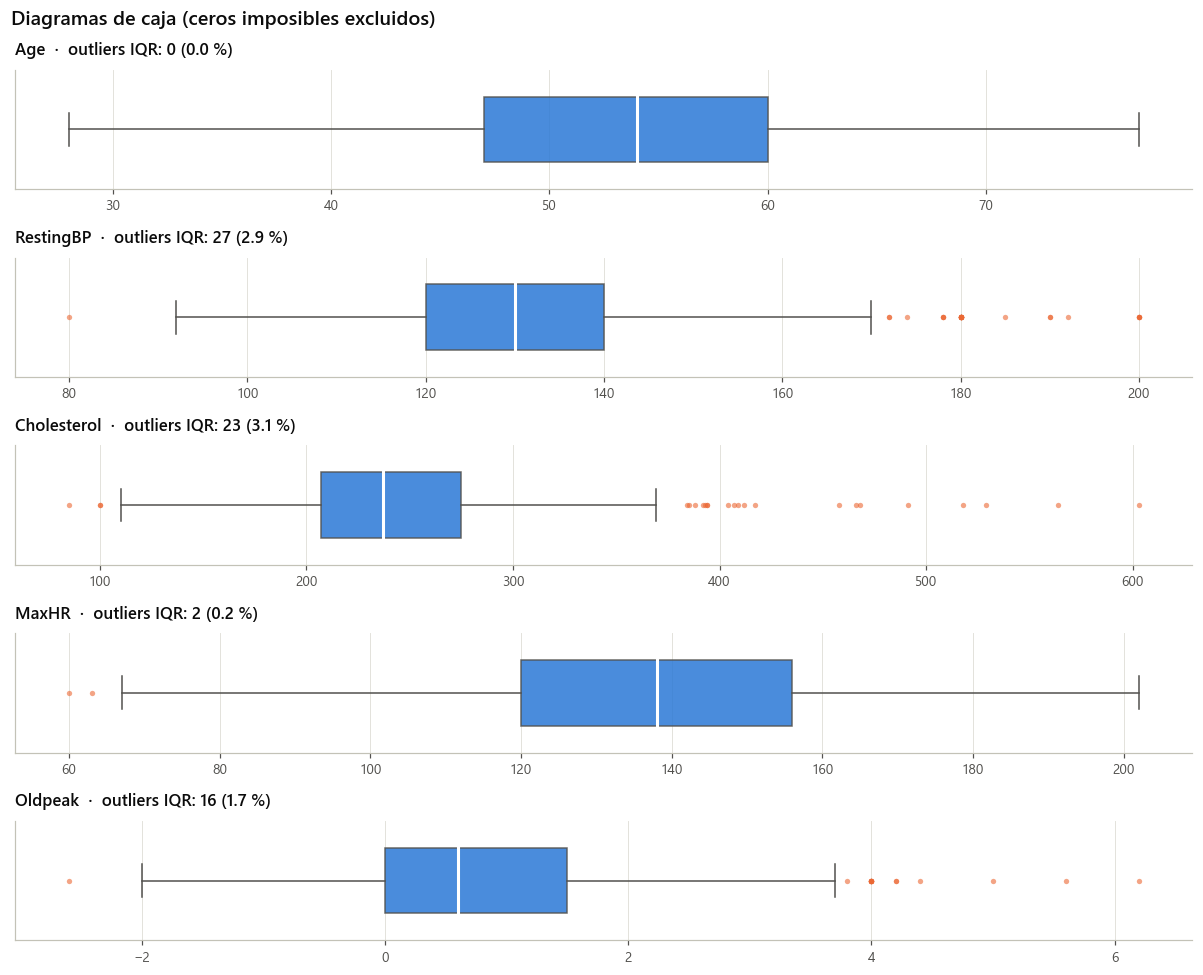

In [11]:
fig, axes = plt.subplots(len(NUM_VARS), 1, figsize=(11, 1.6 * len(NUM_VARS) + 1))
for ax, col in zip(axes, NUM_VARS):
    ax.boxplot(df_eda[col].dropna(), vert=False, widths=0.55, patch_artist=True,
               boxprops=dict(facecolor=COLOR["principal"], edgecolor=COLOR["texto_2"], alpha=0.85),
               medianprops=dict(color="white", linewidth=2),
               whiskerprops=dict(color=COLOR["texto_2"]), capprops=dict(color=COLOR["texto_2"]),
               flierprops=dict(marker="o", markersize=3.5, markerfacecolor=COLOR["secundario"],
                               markeredgecolor="none", alpha=0.6))
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.set_title(f"{col}  ·  outliers IQR: {resumen_num.loc[col, 'n_outliers']} ({resumen_num.loc[col, 'pct_outliers']:.1f} %)")

titulo_figura(fig, "Diagramas de caja (ceros imposibles excluidos)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_boxplots.png")
plt.show()

Los box plots confirman la Parte 8. restingbp y cholesterol tienen outliers en ambos extremos y oldpeak sobre todo en el superior. age no tiene ninguno y maxhr solo dos. Lo cual es coherente, personas con enfermedades cardíacas avanzadas y con valroes tan altos en emogramas son outliers y no es lo común, por eso el modelo deberá centrarse en buscar anomalías por fuera de los rangos "seguros". El dataset debería incluir variables como si hace o no ejercicio, si fuma o no. Ya que son preguntas médicas que van relacionadas al desarrollo de enfermedades, el modelo probablmenete podría encontrar la relación que las personas sedantarias tieneden a desarrollar más enfermedades. 

Parte 11. Normalidad y transformaciones

Con 918 pacientes se puede usar Shapiro-Wilk (admite hasta 5,000 datos). Se reporta también D'Agostino-Pearson como segunda prueba.

,n,asimetria,curtosis,W_Shapiro,p_Shapiro,K2_DAgostino,p_DAgostino,¿normal? (p > 0.05),recomendación
variable,,,,,,,,,
Cholesterol,746,1.24,4.53,0.9357,2.15e-17,205.7,2.20e-45,No,Asimetría fuerte: log o Box-Cox
Oldpeak,918,1.02,1.20,0.8599,8.27e-28,139.1,6.36e-31,No,Asimetría fuerte: Yeo-Johnson (hay ceros o negativos)
RestingBP,917,0.61,0.79,0.9713,1.80e-12,62.8,2.36e-14,No,Asimetría moderada: opcional
Age,918,-0.20,-0.39,0.9910,2.17e-05,14.4,7.51e-04,No,Aprox. simétrica: no requiere
MaxHR,918,-0.14,-0.45,0.9927,1.68e-04,15.8,3.65e-04,No,Aprox. simétrica: no requiere


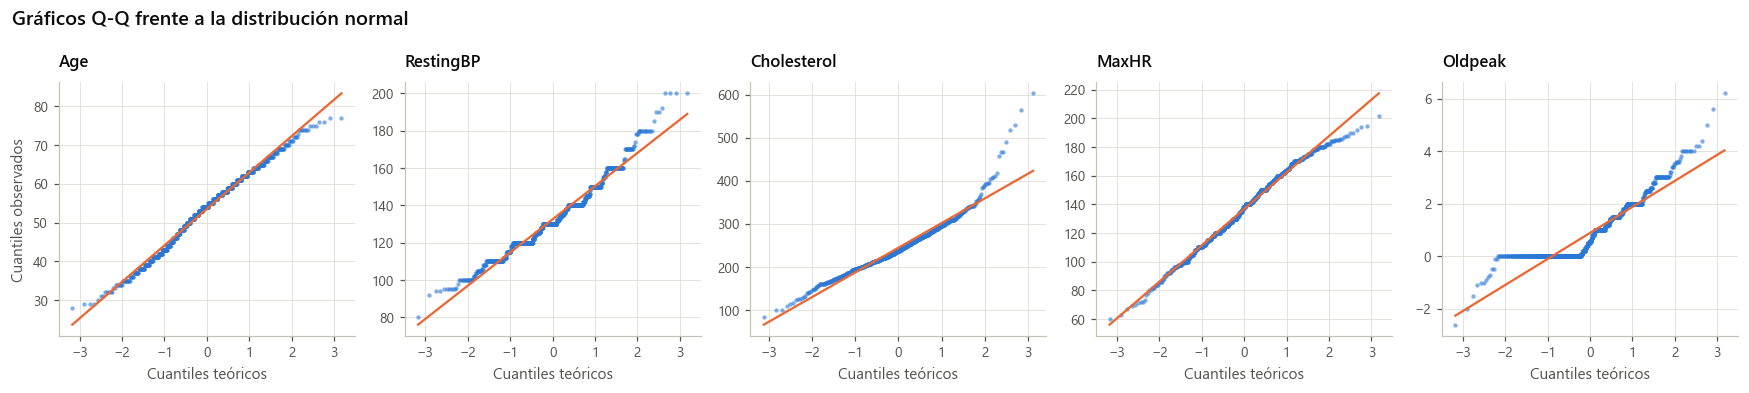

In [12]:
def recomendar_transformacion(asim, minimo):
    if abs(asim) < 0.5:
        return "Aprox. simétrica: no requiere"
    if abs(asim) < 1:
        return "Asimetría moderada: opcional"
    if minimo > 0:
        return "Asimetría fuerte: log o Box-Cox"
    return "Asimetría fuerte: Yeo-Johnson (hay ceros o negativos)"

filas = []
for col in NUM_VARS:
    s = df_eda[col].dropna().astype("float64")
    w, p_sw = stats.shapiro(s)
    k2, p_dp = stats.normaltest(s)
    filas.append({
        "variable": col, "n": len(s),
        "asimetria": s.skew(), "curtosis": s.kurt(),
        "W_Shapiro": w, "p_Shapiro": p_sw,
        "K2_DAgostino": k2, "p_DAgostino": p_dp,
        "¿normal? (p > 0.05)": "Sí" if min(p_sw, p_dp) > 0.05 else "No",
        "recomendación": recomendar_transformacion(s.skew(), s.min()),
    })

normalidad = pd.DataFrame(filas).set_index("variable").sort_values("asimetria", key=abs, ascending=False)
display(normalidad.style.format({"asimetria": "{:.2f}", "curtosis": "{:.2f}", "W_Shapiro": "{:.4f}",
                                 "p_Shapiro": "{:.2e}", "K2_DAgostino": "{:.1f}", "p_DAgostino": "{:.2e}"}))

# Gráficos Q-Q
fig, axes = plt.subplots(1, len(NUM_VARS), figsize=(16, 3.6))
for ax, col in zip(axes, NUM_VARS):
    (osm, osr), (pend, inter, _) = stats.probplot(df_eda[col].dropna(), dist="norm")
    ax.scatter(osm, osr, s=8, color=COLOR["principal"], alpha=0.6, linewidth=0)
    ax.plot(osm, pend * osm + inter, color=COLOR["secundario"], linewidth=1.5)
    ax.set_title(col)
    ax.set_xlabel("Cuantiles teóricos")
axes[0].set_ylabel("Cuantiles observados")
titulo_figura(fig, "Gráficos Q-Q frente a la distribución normal")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_qqplots.png")
plt.show()

Ninguna variable es normal según Shapiro-Wilk ni según D'Agostino-Pearson (todas con p < 0.001). Aun así, el grado de desviación es muy distinto entre variables:

1. age y maxhr: tienen asimetría menor que 0.25 y un W de Shapiro superior a 0.99. Con 918 datos la prueba detecta desviaciones muy pequeñas, pero en la práctica su forma es casi normal.
2. cholesterol (asimetría 1.24) y oldpeak (1.02): tienen asimetría fuerte. En oldpeak hay ceros y negativos, así que no sirve el logaritmo. Si se quisiera transformar, habría que usar Yeo-Johnson.

La decisión para el modelado es no transformar. Los modelos basados en árboles no lo necesitan, y para SVC, KNN y Regresión Logística basta con escalar dentro del Pipeline. La transformación queda como hiperparámetro opcional.

B. Variables categóricas

Parte 12. Frecuencia absoluta y relativa

Como el dataset es pequeño, el umbral de categoría rara es 5 %. 

In [13]:
UMBRAL_RARA = 5   # %

def tabla_frecuencias(data, col):
    abs_ = data[col].value_counts(dropna=False)
    tabla = pd.DataFrame({"frecuencia": abs_, "porcentaje": abs_ / len(data) * 100})
    tabla.index = tabla.index.astype(str)
    tabla.index.name = col
    tabla["baja_frecuencia"] = np.where(tabla["porcentaje"] < UMBRAL_RARA, "Sí", "")
    return tabla

frecuencias = {col: tabla_frecuencias(df, col) for col in CAT_VARS}

resumen_cat = pd.DataFrame([{
    "variable": col,
    "n_categorias": len(t),
    "categoria_mas_frecuente": t.index[0],
    "pct_mas_frecuente": t["porcentaje"].iloc[0],
    "categoria_menos_frecuente": t.index[-1],
    "pct_menos_frecuente": t["porcentaje"].iloc[-1],
    f"n_bajo_{UMBRAL_RARA}pct": int((t["porcentaje"] < UMBRAL_RARA).sum()),
} for col, t in frecuencias.items()]).set_index("variable")
display(resumen_cat.style.format({"pct_mas_frecuente": "{:.1f} %", "pct_menos_frecuente": "{:.1f} %"}))

for col in CAT_VARS:
    print(f"\n{col}  ({df[col].nunique()} categorías)")
    display(frecuencias[col].style.format({"frecuencia": "{:,}", "porcentaje": "{:.2f} %"}))

,n_categorias,categoria_mas_frecuente,pct_mas_frecuente,categoria_menos_frecuente,pct_menos_frecuente,n_bajo_5pct
variable,,,,,,
Sex,2,M,79.0 %,F,21.0 %,0
ChestPainType,4,ASY,54.0 %,TA,5.0 %,0
FastingBS,2,0,76.7 %,1,23.3 %,0
RestingECG,3,Normal,60.1 %,ST,19.4 %,0
ExerciseAngina,2,N,59.6 %,Y,40.4 %,0
ST_Slope,3,Flat,50.1 %,Down,6.9 %,0



Sex  (2 categorías)


,frecuencia,porcentaje,baja_frecuencia
Sex,,,
M,725,78.98 %,
F,193,21.02 %,



ChestPainType  (4 categorías)


,frecuencia,porcentaje,baja_frecuencia
ChestPainType,,,
ASY,496,54.03 %,
NAP,203,22.11 %,
ATA,173,18.85 %,
TA,46,5.01 %,


...

,frecuencia,porcentaje,baja_frecuencia
RestingECG,,,
Normal,552,60.13 %,
LVH,188,20.48 %,
ST,178,19.39 %,



ExerciseAngina  (2 categorías)


,frecuencia,porcentaje,baja_frecuencia
ExerciseAngina,,,
N,547,59.59 %,
Y,371,40.41 %,



ST_Slope  (3 categorías)


,frecuencia,porcentaje,baja_frecuencia
ST_Slope,,,
Flat,460,50.11 %,
Up,395,43.03 %,
Down,63,6.86 %,


Parte 13. Gráficos de barras

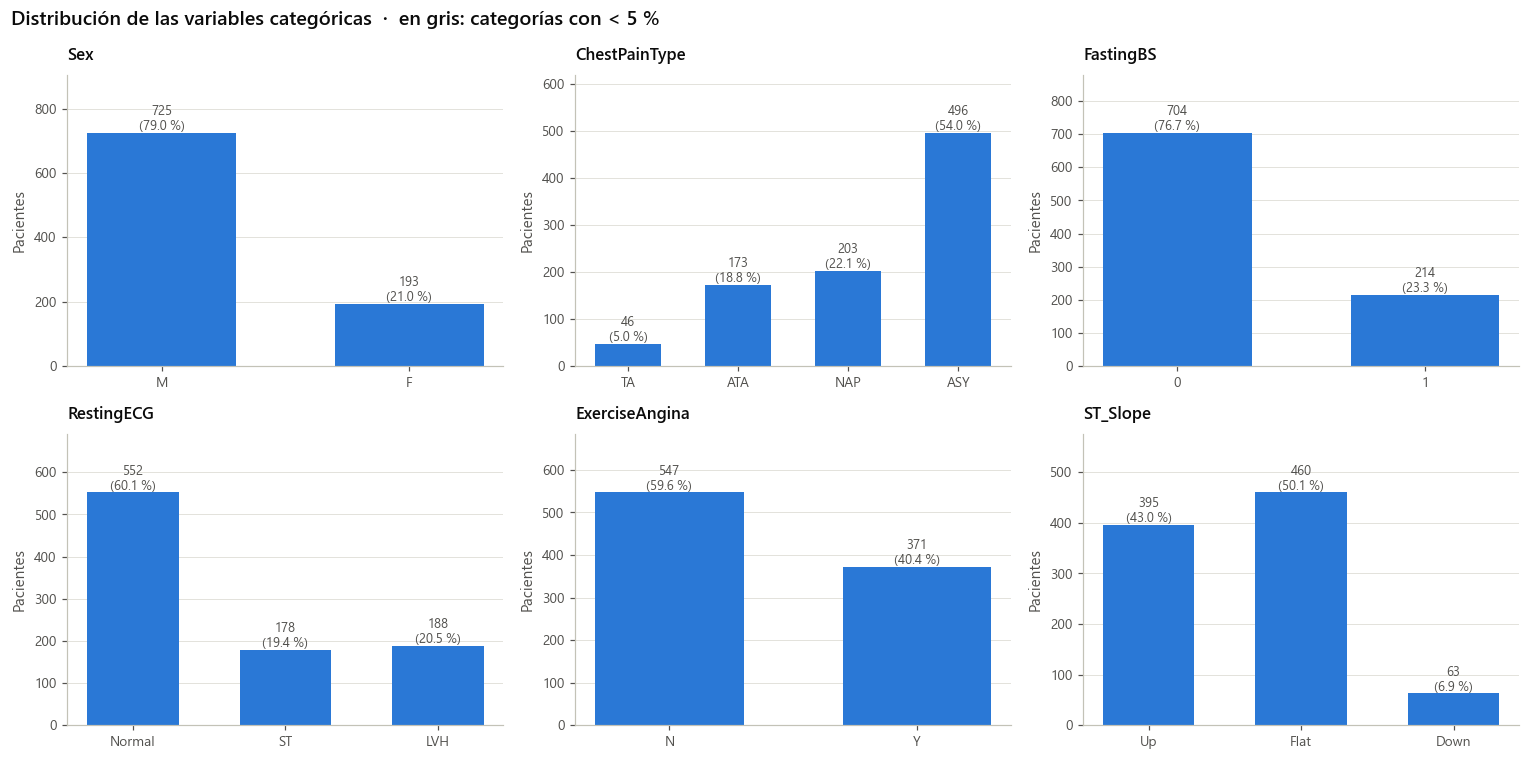

In [14]:
ORDEN = {
    "ChestPainType": ["TA", "ATA", "NAP", "ASY"],
    "RestingECG": ["Normal", "ST", "LVH"],
    "ST_Slope": ["Up", "Flat", "Down"],
    "FastingBS": ["0", "1"],
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, CAT_VARS):
    t = frecuencias[col]
    t = t.loc[[c for c in ORDEN[col] if c in t.index]] if col in ORDEN else t
    colores = np.where(t["baja_frecuencia"] == "Sí", COLOR["tenue"], COLOR["principal"])
    barras = ax.bar(t.index, t["frecuencia"], color=colores, width=0.6)
    for barra, f, p in zip(barras, t["frecuencia"], t["porcentaje"]):
        ax.text(barra.get_x() + barra.get_width() / 2, f, f"{f}\n({p:.1f} %)",
                ha="center", va="bottom", fontsize=8.5, color=COLOR["texto_2"])
    ax.set_ylim(0, t["frecuencia"].max() * 1.25)
    ax.set_title(col)
    ax.set_ylabel("Pacientes")
    ax.grid(axis="x", visible=False)

titulo_figura(fig, f"Distribución de las variables categóricas  ·  en gris: categorías con < {UMBRAL_RARA} %")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_barras_categoricas.png")
plt.show()

1. El dataset está muy desbalanceado: 79 % hombres y 21 % mujeres.
2. chestpaintype: la categoría más frecuente es ASY, dolor asintomático (54 %). TA, angina típica, queda justo en el umbral (5.0 %, 46 pacientes).
3. st_slope: casi todos los pacientes tienen pendiente Flat o Up, y Down es poco frecuente (6.9 %).
4. fastingbs y exerciseangina: están desbalanceadas pero con suficientes casos en cada clase.

Ninguna categoría queda por debajo del 5 %, así que no hace falta agrupar categorías raras u "otros", como se hizo en la priemra tarea

C. Variable objetivo

Parte 14. Distribución de heartdisease

,frecuencia,porcentaje
0 · Sin enfermedad,410,44.66 %
1 · Con enfermedad,508,55.34 %


Razón de clases (1 : 0) = 1.24 : 1


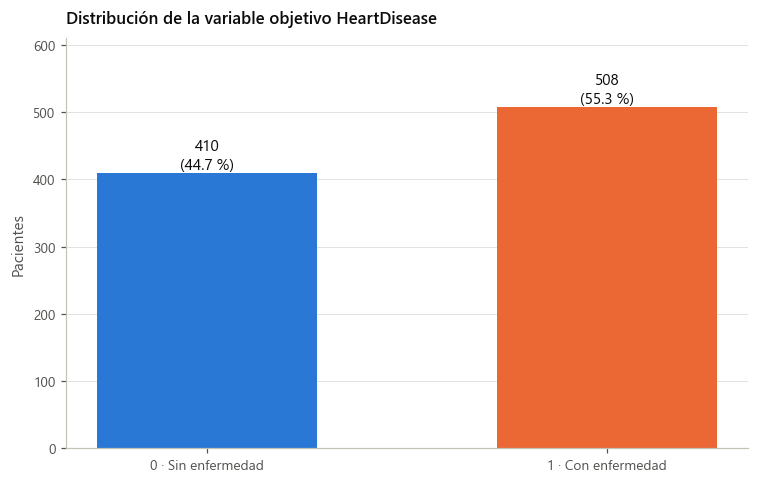

In [15]:
clases = df[TARGET].value_counts().sort_index().to_frame("frecuencia")
clases["porcentaje"] = clases["frecuencia"] / len(df) * 100
clases.index = [f"{k} · {CLASE_NOMBRE[k]}" for k in clases.index]
display(clases.style.format({"porcentaje": "{:.2f} %"}))
print(f"Razón de clases (1 : 0) = {clases['frecuencia'].iloc[1] / clases['frecuencia'].iloc[0]:.2f} : 1")

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(clases.index, clases["frecuencia"], color=[CLASE_COLOR[0], CLASE_COLOR[1]], width=0.55)
for barra, f, p in zip(barras, clases["frecuencia"], clases["porcentaje"]):
    ax.text(barra.get_x() + barra.get_width() / 2, f, f"{f:,}\n({p:.1f} %)",
            ha="center", va="bottom", fontsize=10, color=COLOR["texto"])
ax.set_ylabel("Pacientes")
ax.set_ylim(0, clases["frecuencia"].max() * 1.2)
ax.grid(axis="x", visible=False)
ax.set_title("Distribución de la variable objetivo HeartDisease")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_variable_objetivo.png")
plt.show()

Hay 508 pacientes con enfermedad (55.3 %) y 410 sin ella (44.7 %), una razón de 1.24 : 1. El desbalance es leve, así que no hace falta sobremuestreo ni pesos de clase.

1. El split train/test se hará estratificado para conservar la proporción.
2. La métrica principal será AUC, que no depende del umbral, y se reportará también Accuracy, como pide el enunciado.
3. El modelo trivial que siempre predice "con enfermedad" tendría 55.3 % de accuracy. Ese es el piso que cualquier modelo tiene que superar. También conviene no tener falsos positivos porque en el mundo real se iniciarían tratamientos que pueden ser invasivos con medicamentos fuertes, que podrían terminar por agravar o dañar otros órganos. Por ejemplo, usar muchso analgésicos y pastillas para la presión daña los riñones.

Preparación

A. Variables numéricas vs heartdisease

Parte 15. Boxplots y violin plots por clase

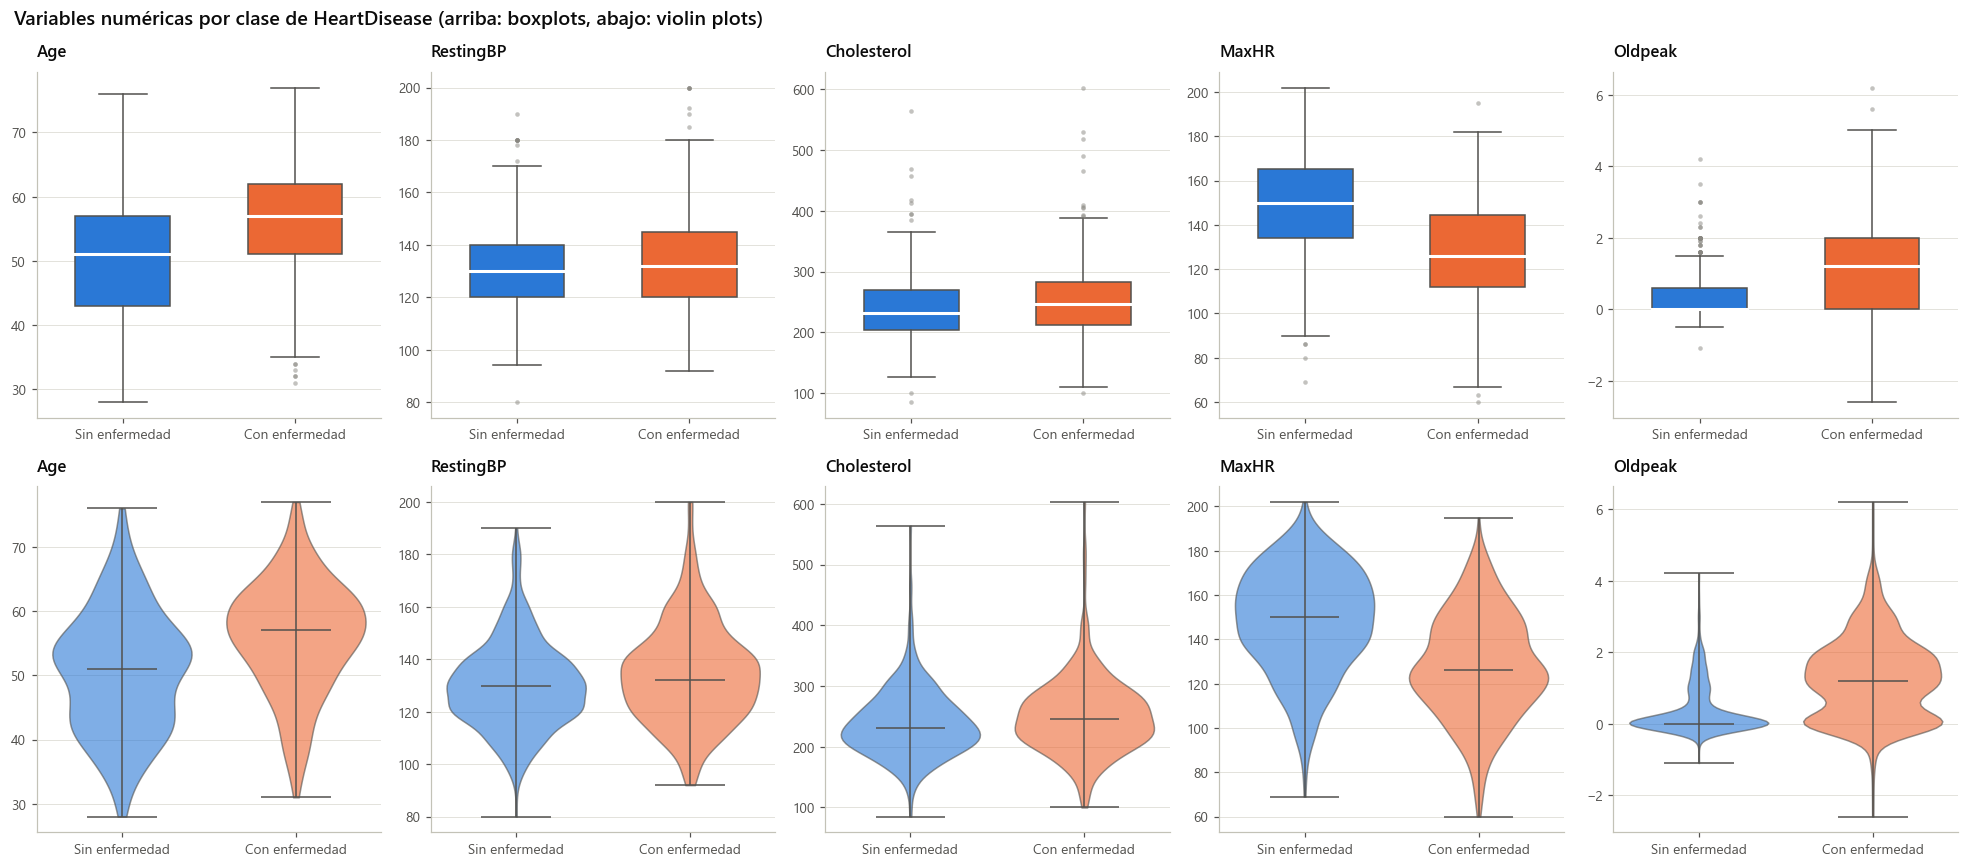

In [16]:
fig, axes = plt.subplots(2, len(NUM_VARS), figsize=(18, 8))
for j, col in enumerate(NUM_VARS):
    datos = df_eda[[col, TARGET]].dropna()

    # Fila 1: boxplots
    ax = axes[0, j]
    cajas = ax.boxplot([datos.loc[datos[TARGET] == k, col] for k in (0, 1)], widths=0.55, patch_artist=True,
                       medianprops=dict(color="white", linewidth=2),
                       whiskerprops=dict(color=COLOR["texto_2"]), capprops=dict(color=COLOR["texto_2"]),
                       flierprops=dict(marker="o", markersize=3, markerfacecolor=COLOR["tenue"],
                                       markeredgecolor="none", alpha=0.5))
    for caja, k in zip(cajas["boxes"], (0, 1)):
        caja.set(facecolor=CLASE_COLOR[k], edgecolor=COLOR["texto_2"])
    ax.set_xticks([1, 2], [CLASE_NOMBRE[0], CLASE_NOMBRE[1]])
    ax.set_title(col)
    ax.grid(axis="x", visible=False)

    # Fila 2: violines
    ax = axes[1, j]
    partes = ax.violinplot([datos.loc[datos[TARGET] == k, col] for k in (0, 1)], showmedians=True, widths=0.8)
    for cuerpo, k in zip(partes["bodies"], (0, 1)):
        cuerpo.set(facecolor=CLASE_COLOR[k], edgecolor=COLOR["texto_2"], alpha=0.6)
    for clave in ("cbars", "cmins", "cmaxes", "cmedians"):
        partes[clave].set(color=COLOR["texto_2"], linewidth=1)
    ax.set_xticks([1, 2], [CLASE_NOMBRE[0], CLASE_NOMBRE[1]])
    ax.set_title(col)
    ax.grid(axis="x", visible=False)

titulo_figura(fig, "Variables numéricas por clase de HeartDisease (arriba: boxplots, abajo: violin plots)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_boxplots_violines_por_clase.png")
plt.show()

1. oldpeak: es la variable que mejor separa las clases. Sin enfermedad, la mediana es 0 y la distribución está concentrada. Con enfermedad, la mediana es 1.2 y los valores están mucho más dispersos.
2. maxhr: se comporta al revés. Los pacientes enfermos alcanzan una frecuencia cardíaca máxima menor (mediana 126 contra 150), lo que es coherente con la menor capacidad de ejercicio.
3. age: los enfermos son unos 6 años mayores (57 contra 51).
4. restingbp y cholesterol: las cajas se solapan casi por completo, así que por sí solas diferencian poco.

Parte 16. Diferencias de medias, t de Welch, Mann-Whitney y correlación punto biserial

En la Parte 11 ninguna variable resultó normal, así que la prueba principal es Mann-Whitney; la t de Welch se reporta para comparar. El tamaño del efecto se mide con la correlación rank-biserial (|r| < 0.1 despreciable, < 0.3 pequeño, < 0.5 mediano, ≥ 0.5 grande).

In [17]:
def magnitud(r):
    r = abs(r)
    return "Despreciable" if r < 0.1 else "Pequeño" if r < 0.3 else "Mediano" if r < 0.5 else "Grande"

filas = []
for col in NUM_VARS:
    datos = df_eda[[col, TARGET]].dropna()
    x0 = datos.loc[datos[TARGET] == 0, col]
    x1 = datos.loc[datos[TARGET] == 1, col]
    t_stat, p_t = stats.ttest_ind(x1, x0, equal_var=False)
    u_stat, p_u = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    r_pb, _ = stats.pointbiserialr(datos[TARGET], datos[col])
    r_rb = 2 * u_stat / (len(x0) * len(x1)) - 1
    filas.append({
        "variable": col, "n_0": len(x0), "n_1": len(x1),
        "media_0": x0.mean(), "media_1": x1.mean(), "dif_medias": x1.mean() - x0.mean(),
        "mediana_0": x0.median(), "mediana_1": x1.median(),
        "t_Welch": t_stat, "p_t": p_t, "p_MannWhitney": p_u,
        "r_rank_biserial": r_rb, "r_punto_biserial": r_pb,
        "efecto": magnitud(r_rb),
        "significativa (p<0.05)": "Sí" if p_u < 0.05 else "No",
    })

pruebas_num = pd.DataFrame(filas).set_index("variable").sort_values("r_punto_biserial", key=abs, ascending=False)
display(pruebas_num.style.format({
    "media_0": "{:.2f}", "media_1": "{:.2f}", "dif_medias": "{:+.2f}", "mediana_0": "{:.2f}", "mediana_1": "{:.2f}",
    "t_Welch": "{:.2f}", "p_t": "{:.2e}", "p_MannWhitney": "{:.2e}",
    "r_rank_biserial": "{:+.3f}", "r_punto_biserial": "{:+.3f}"}))

,n_0,n_1,media_0,media_1,dif_medias,mediana_0,mediana_1,t_Welch,p_t,p_MannWhitney,r_rank_biserial,r_punto_biserial,efecto,significativa (p<0.05)
variable,,,,,,,,,,,,,,
Oldpeak,410,508,0.41,1.27,+0.87,0.00,1.20,14.04,1.90e-40,6.77e-37,+0.470,+0.404,Mediano,Sí
MaxHR,410,508,148.15,127.66,-20.50,150.00,126.00,-13.23,1.43e-36,1.51e-34,-0.470,-0.400,Mediano,Sí
Age,410,508,50.55,55.90,+5.35,51.00,57.00,8.82,6.35e-18,1.81e-18,+0.336,+0.282,Mediano,Sí
RestingBP,410,507,130.18,134.45,+4.27,130.00,132.00,3.65,2.81e-04,4.57e-04,+0.134,+0.118,Pequeño,Sí
Cholesterol,390,356,238.77,251.06,+12.29,231.50,246.00,2.83,4.74e-03,1.71e-03,+0.133,+0.104,Pequeño,Sí


Las 5 variables tienen diferencias significativas (p < 0.05) según Mann-Whitney y t de Welch, pero el tamaño del efecto no es el mismo:

1. Efecto mediano: oldpeak (r = +0.47), maxhr (r = −0.47) y age (r = +0.34).
2. Efecto pequeño: restingbp (+0.13) y cholesterol (+0.13).

El colesterol, que clínicamente es un factor de riesgo clásico, resulta de las variables menos discriminantes en este dataset. Parte de la razón es que el 18.7 % de sus valores faltan y quedan fuera de la prueba. Además, la Parte 24 muestra que el hecho de que falte sí está muy relacionado con la enfermedad.COnla presión pasa algo similar. Otra posible mejora sería la posibilidad de remisión o no con otras especialidad, por ejemplo, presión alta daña riñones, glucosa alta higado y páncreas, presión alta y glucosa alta dañan la retina. El profesor podría explorar la psobilidad de incluirlo como algo opcional para la tarea. 

Parte 17. KDE comparativos por clase

Las variables se ordenan por |r punto biserial| de la Parte 16.

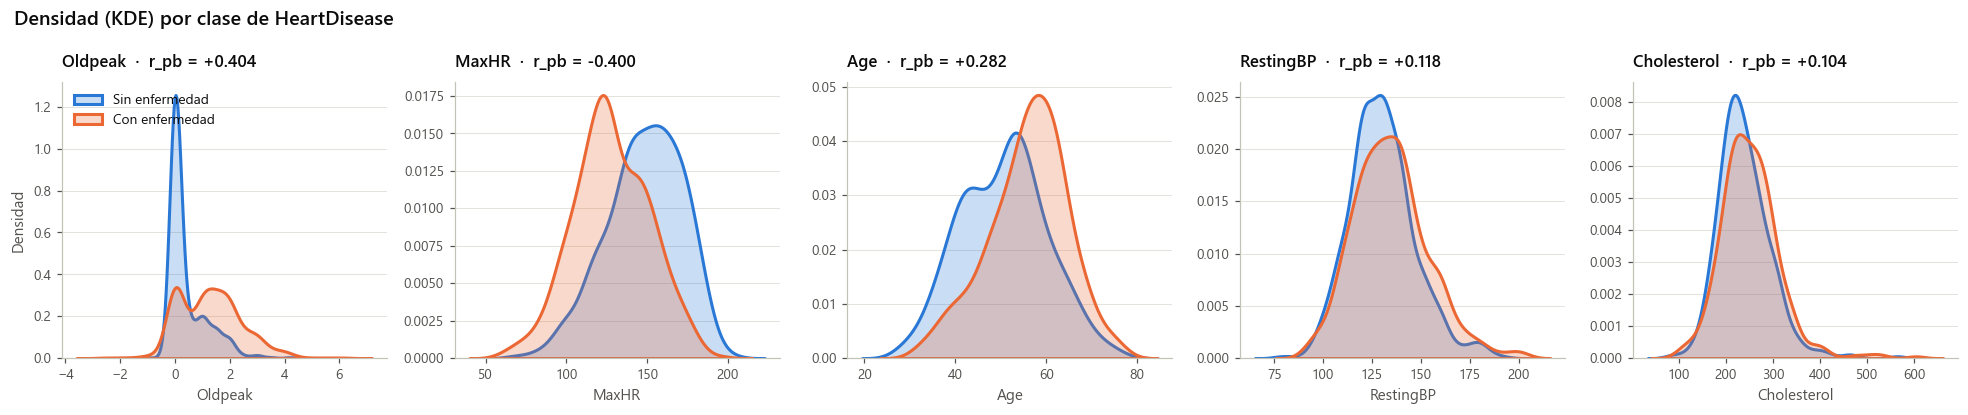

In [18]:
fig, axes = plt.subplots(1, len(NUM_VARS), figsize=(18, 3.8))
for ax, col in zip(axes, pruebas_num.index):
    datos = df_eda[[col, TARGET]].dropna()
    for k in (0, 1):
        sns.kdeplot(datos.loc[datos[TARGET] == k, col], ax=ax, color=CLASE_COLOR[k],
                    fill=True, alpha=0.25, linewidth=2, label=CLASE_NOMBRE[k])
    ax.set_title(f"{col}  ·  r_pb = {pruebas_num.loc[col, 'r_punto_biserial']:+.3f}")
    ax.set_ylabel("Densidad" if ax is axes[0] else "")
    ax.grid(axis="x", visible=False)
axes[0].legend(loc="upper left")
titulo_figura(fig, "Densidad (KDE) por clase de HeartDisease")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_kde_por_clase.png")
plt.show()

Las curvas KDE confirman el orden. En oldpeak y maxhr las densidades de las dos clases están claramente desplazadas. En age el desplazamiento es moderado, y en restingbp y cholesterol las curvas casi se superponen.

B. Variables categóricas vs heartdisease

Parte 18. Tablas de contingencia, chi cuadrado y V de Cramér

La V de Cramér va de 0 a 1 y mide la fuerza de la asociación. Para saber qué categorías explican la asociación se usan los residuos estandarizados ajustados, con corrección de Bonferroni.

In [19]:
ALFA = 0.05

def cramer_v(tabla):
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    n = tabla.values.sum()
    k = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

def magnitud_v(v):
    return "Despreciable" if v < 0.1 else "Pequeña" if v < 0.3 else "Moderada" if v < 0.5 else "Grande"

TASA_GLOBAL = df[TARGET].mean() * 100
tablas_cat, filas = {}, []
for col in CAT_VARS:
    conteos = pd.crosstab(df[col].astype(str), df[TARGET])
    conteos.columns = ["n_sin_enfermedad", "n_con_enfermedad"]
    tabla = conteos.assign(n_total=conteos.sum(axis=1))
    tabla["tasa_enfermedad"] = tabla["n_con_enfermedad"] / tabla["n_total"] * 100
    tabla["dif_vs_global"] = tabla["tasa_enfermedad"] - TASA_GLOBAL

    chi2, p, gl, esperadas = stats.chi2_contingency(conteos)
    n = conteos.values.sum()
    prop_fila = conteos.sum(axis=1).values[:, None] / n
    prop_col = conteos.sum(axis=0).values[None, :] / n
    residuos = (conteos.values - esperadas) / np.sqrt(esperadas * (1 - prop_fila) * (1 - prop_col))
    tabla["residuo_ajustado"] = residuos[:, 1]
    critico = stats.norm.ppf(1 - ALFA / (2 * len(conteos)))     # corrección de Bonferroni
    tabla["significativa_posthoc"] = np.where(np.abs(tabla["residuo_ajustado"]) > critico, "Sí", "No")
    tablas_cat[col] = tabla

    v = cramer_v(conteos)
    filas.append({"variable": col, "n_categorias": len(conteos), "chi2": chi2, "gl": gl, "p_value": p,
                  "V_Cramer": v, "magnitud": magnitud_v(v),
                  "pct_esperadas_<5": (esperadas < 5).mean() * 100,
                  "significativa (p<0.05)": "Sí" if p < ALFA else "No"})

pruebas_cat = pd.DataFrame(filas).set_index("variable").sort_values("V_Cramer", ascending=False)
display(pruebas_cat.style.format({"chi2": "{:.1f}", "p_value": "{:.2e}", "V_Cramer": "{:.3f}",
                                  "pct_esperadas_<5": "{:.0f} %"}))

for col in pruebas_cat.index:
    print(f"\n{col}  ·  χ² = {pruebas_cat.loc[col, 'chi2']:.1f}  ·  {fmt_p(pruebas_cat.loc[col, 'p_value'])}"
          f"  ·  V = {pruebas_cat.loc[col, 'V_Cramer']:.3f}")
    display(tablas_cat[col].style.format({"tasa_enfermedad": "{:.1f} %", "dif_vs_global": "{:+.1f}",
                                          "residuo_ajustado": "{:+.2f}"}))

,n_categorias,chi2,gl,p_value,V_Cramer,magnitud,pct_esperadas_<5,significativa (p<0.05)
variable,,,,,,,,
ST_Slope,3,355.9,2,5.17e-78,0.623,Grande,0 %,Sí
ChestPainType,4,268.1,3,8.08e-58,0.540,Grande,0 %,Sí
ExerciseAngina,2,222.3,1,2.91e-50,0.494,Moderada,0 %,Sí
Sex,2,84.1,1,4.60e-20,0.305,Moderada,0 %,Sí
FastingBS,2,64.3,1,1.06e-15,0.267,Pequeña,0 %,Sí
RestingECG,3,10.9,2,4.23e-03,0.109,Pequeña,0 %,Sí



ST_Slope  ·  χ² = 355.9  ·  p < 0.001  ·  V = 0.623


,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad,dif_vs_global,residuo_ajustado,significativa_posthoc
ST_Slope,,,,,,,
Down,14,49,63,77.8 %,+22.4,+3.71,Sí
Flat,79,381,460,82.8 %,+27.5,+16.79,Sí
Up,317,78,395,19.7 %,-35.6,-18.85,Sí



ChestPainType  ·  χ² = 268.1  ·  p < 0.001  ·  V = 0.540


,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad,dif_vs_global,residuo_ajustado,significativa_posthoc
ChestPainType,,,,,,,
ASY,104,392,496,79.0 %,+23.7,+15.66,Sí
ATA,149,24,173,13.9 %,-41.5,-12.18,Sí
NAP,131,72,203,35.5 %,-19.9,-6.45,Sí
TA,26,20,46,43.5 %,-11.9,-1.66,No


...

,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad,dif_vs_global,residuo_ajustado,significativa_posthoc
Sex,,,,,,,
F,143,50,193,25.9 %,-29.4,-9.25,Sí
M,267,458,725,63.2 %,+7.8,+9.25,Sí



FastingBS  ·  χ² = 64.3  ·  p < 0.001  ·  V = 0.267


,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad,dif_vs_global,residuo_ajustado,significativa_posthoc
FastingBS,,,,,,,
0,366,338,704,48.0 %,-7.3,-8.10,Sí
1,44,170,214,79.4 %,+24.1,+8.10,Sí



RestingECG  ·  χ² = 10.9  ·  p = 0.004  ·  V = 0.109


,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad,dif_vs_global,residuo_ajustado,significativa_posthoc
RestingECG,,,,,,,
LVH,82,106,188,56.4 %,+1.0,+0.32,No
Normal,267,285,552,51.6 %,-3.7,-2.77,Sí
ST,61,117,178,65.7 %,+10.4,+3.11,Sí


Las 6 variables categóricas están asociadas significativamente con heartdisease, y ninguna celda tiene frecuencia esperada menor que 5, así que la prueba χ² es válida. Ordenadas por V de Cramér:

| Variable | V | Magnitud | Categoría de mayor riesgo |
|---|---|---|---|
| st_slope | 0.623 | Grande | Flat (82.8 %) y Down (77.8 %); Up solo 19.7 % |
| chestpaintype | 0.540 | Grande | ASY asintomático (79.0 %); ATA solo 13.9 % |
| exerciseangina | 0.494 | Moderada | Y (85.2 %) contra N (35.1 %) |
| sex | 0.305 | Moderada | M (63.2 %) contra F (25.9 %) |
| fastingbs | 0.267 | Pequeña | 1 (79.4 %) contra 0 (48.0 %) |
| restingecg | 0.109 | Pequeña | ST (65.7 %) |

Hay un resultado contraintuitivo: el dolor asintomático (ASY) es el de mayor riesgo. Los pacientes sin síntomas típicos llegan a la prueba con la enfermedad ya avanzada, mientras que la angina atípica suele tener otras causas. En chestpaintype, la categoría TA no difiere significativamente de la tasa global después de la corrección de Bonferroni. En restingecg, tampoco LVH.

Parte 19. Barras apiladas y tasa de enfermedad por categoría

A la izquierda, la frecuencia apilada por clase; a la derecha, la tasa de enfermedad cardíaca comparada con la global.

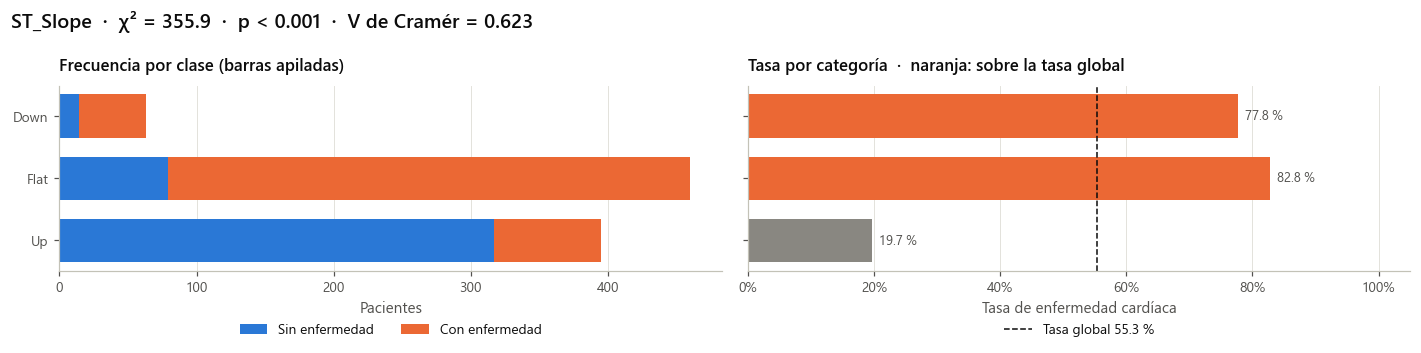

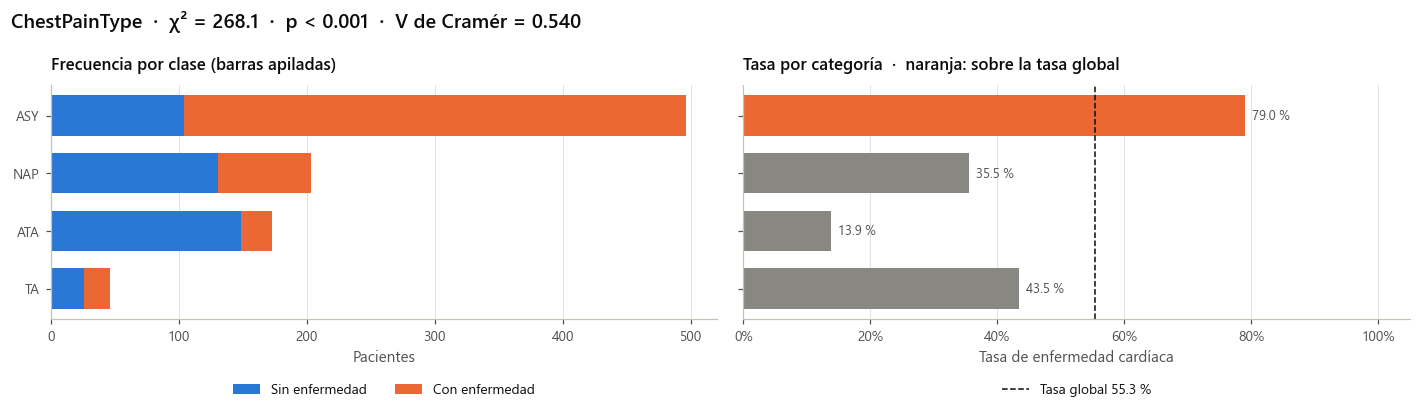

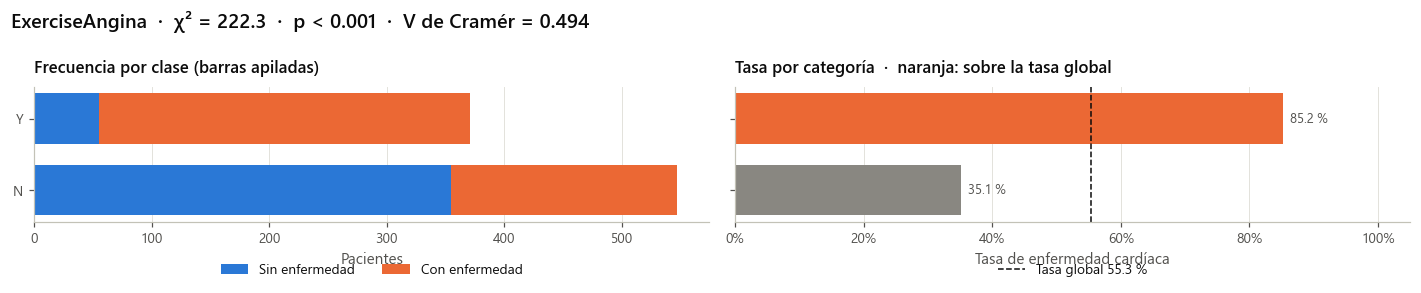

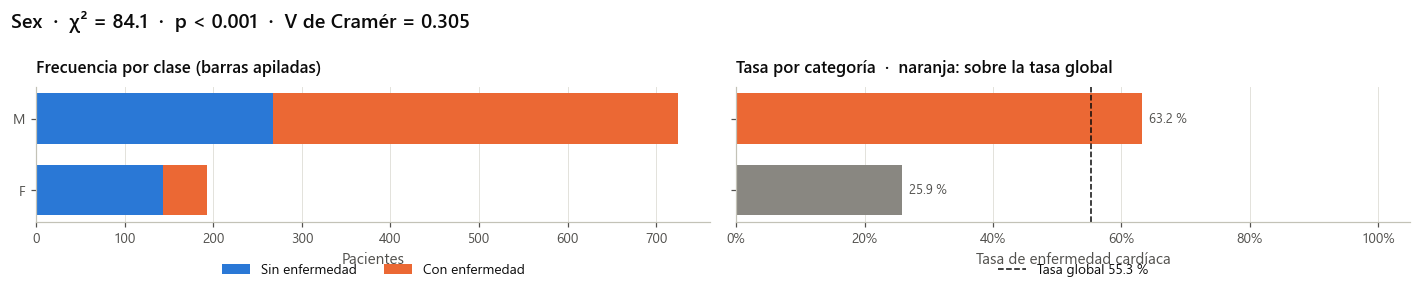

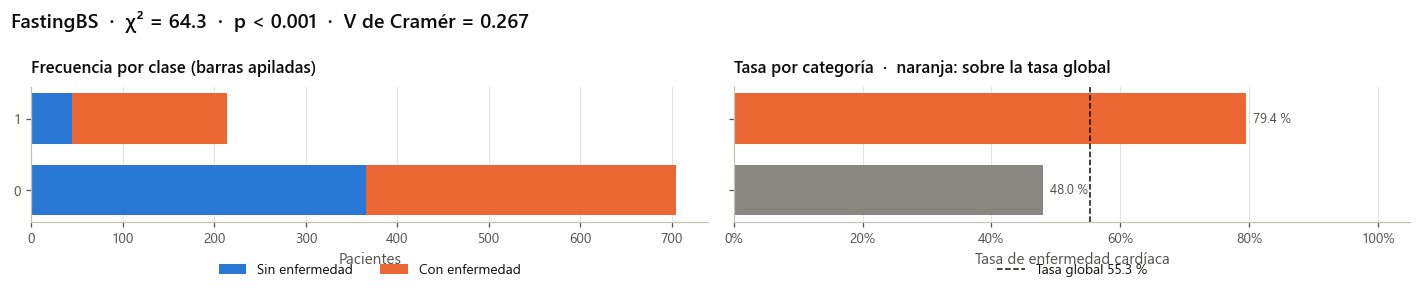

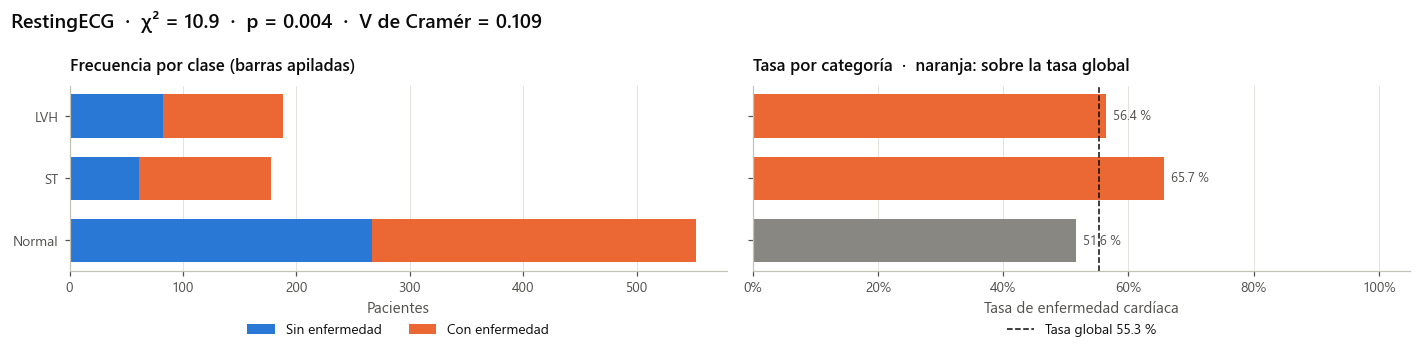

In [20]:
for col in pruebas_cat.index:
    tabla = tablas_cat[col]
    tabla = tabla.loc[[c for c in ORDEN[col] if c in tabla.index]] if col in ORDEN else tabla.sort_values("tasa_enfermedad")
    n = len(tabla)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 0.55 * n + 1.8), sharey=True)
    ax1.barh(tabla.index, tabla["n_sin_enfermedad"], color=CLASE_COLOR[0], height=0.7, label=CLASE_NOMBRE[0])
    ax1.barh(tabla.index, tabla["n_con_enfermedad"], left=tabla["n_sin_enfermedad"], color=CLASE_COLOR[1],
             height=0.7, label=CLASE_NOMBRE[1])
    ax1.set_xlabel("Pacientes")
    ax1.set_title("Frecuencia por clase (barras apiladas)")
    ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)

    ax2.barh(tabla.index, tabla["tasa_enfermedad"], height=0.7,
             color=np.where(tabla["tasa_enfermedad"] > TASA_GLOBAL, COLOR["secundario"], COLOR["tenue"]))
    ax2.axvline(TASA_GLOBAL, color=COLOR["texto"], linestyle="--", linewidth=1, label=f"Tasa global {TASA_GLOBAL:.1f} %")
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22))
    for i, v in enumerate(tabla["tasa_enfermedad"]):
        ax2.text(v, i, f"  {v:.1f} %", va="center", fontsize=8.5, color=COLOR["texto_2"])
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_xlim(0, 105)
    ax2.set_xlabel("Tasa de enfermedad cardíaca")
    ax2.set_title("Tasa por categoría  ·  naranja: sobre la tasa global")

    for ax in (ax1, ax2):
        ax.grid(axis="y", visible=False)

    fila = pruebas_cat.loc[col]
    titulo_figura(fig, f"{col}  ·  χ² = {fila['chi2']:.1f}  ·  {fmt_p(fila['p_value'])}  ·  V de Cramér = {fila['V_Cramer']:.3f}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"01_tasa_por_{col}.png")
    plt.show()

Las barras naranjas marcan las categorías con tasa por encima de la global (55.3 %). Las más riesgosas son exerciseangina = Y (85.2 %), st_slope = Flat (82.8 %), fastingbs = 1 (79.4 %) y chestpaintype = ASY (79.0 %). Las que más protegen son chestpaintype = ATA (13.9 %) y st_slope = Up (19.7 %).

C. Multicolinealidad

Parte 20. Correlación de Pearson y Spearman entre variables numéricas

Como las variables no son normales (Parte 11), se muestra también Spearman, que se basa en rangos y no asume linealidad.

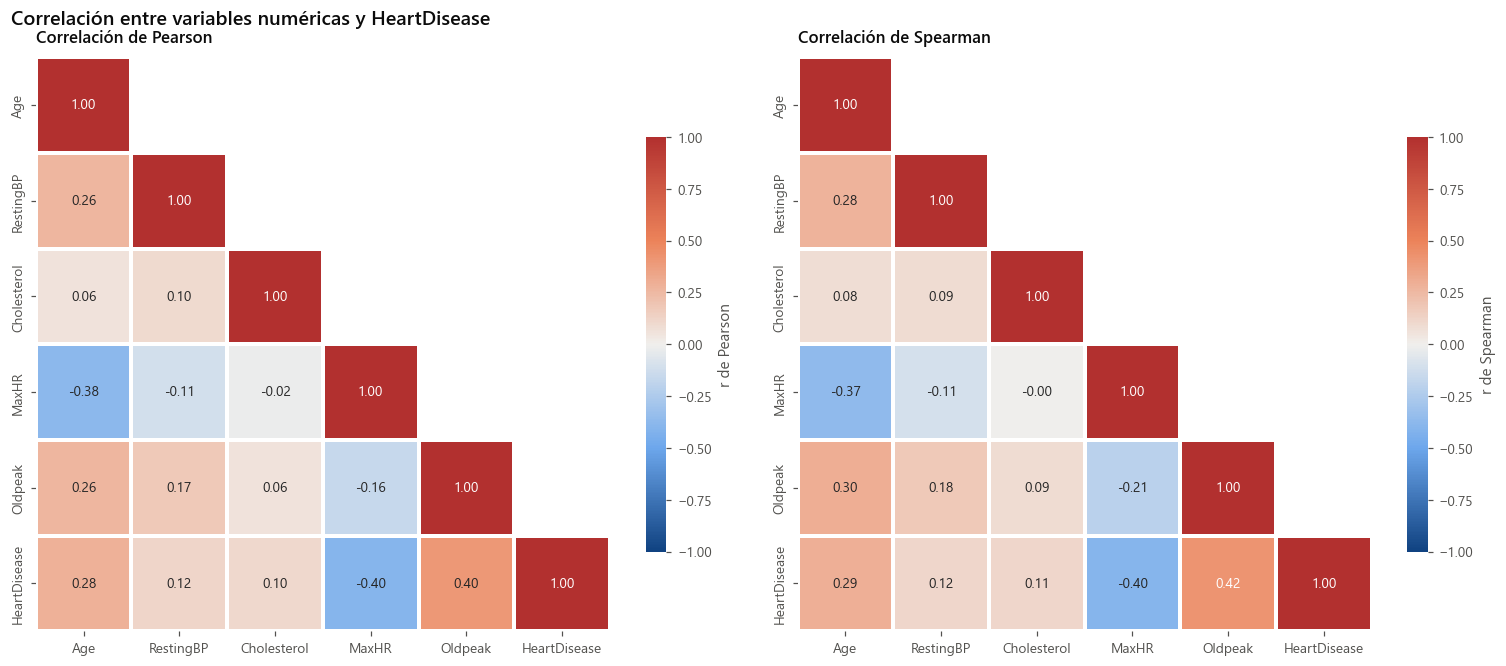

Pares con |r| > 0.7: 0


In [21]:
cols_corr = NUM_VARS + [TARGET]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metodo in zip(axes, ["pearson", "spearman"]):
    corr = df_eda[cols_corr].corr(method=metodo)
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap=CMAP_DIV, vmin=-1, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 9}, linewidths=1.5, linecolor="white", square=True,
                cbar_kws={"shrink": 0.7, "label": f"r de {metodo.capitalize()}"}, ax=ax)
    ax.grid(False)
    ax.set_title(f"Correlación de {metodo.capitalize()}")
titulo_figura(fig, "Correlación entre variables numéricas y HeartDisease")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_heatmap_correlacion.png")
plt.show()

corr_p = df_eda[NUM_VARS].corr()
pares = (corr_p.where(np.triu(np.ones_like(corr_p, dtype=bool), k=1)).stack()
         .rename("r_pearson").to_frame().sort_values("r_pearson", key=abs, ascending=False))
print(f"Pares con |r| > 0.7: {(pares['r_pearson'].abs() > 0.7).sum()}")
display(pares.head(5).style.format("{:+.3f}"))

No hay multicolinealidad entre las variables numéricas: ningún par supera |r| = 0.7. El par más correlacionado es age con maxhr (r = −0.38), porque la frecuencia cardíaca máxima baja con la edad. Pearson y Spearman dan resultados parecidos. Con la variable objetivo, las correlaciones más fuertes son las de oldpeak (Spearman +0.42) y maxhr (−0.41). Se conservan las 5 variables numéricas. Se usaría Pearson para un reporte hipotético. 

Parte 21. V de Cramér entre pares de variables categóricas

variable_1,variable_2,chi2,p_value,V_Cramer
ST_Slope,HeartDisease,355.9,5.17e-78,0.623
ChestPainType,HeartDisease,268.1,8.08e-58,0.540
ExerciseAngina,HeartDisease,222.3,2.91e-50,0.494
ExerciseAngina,ST_Slope,191.4,2.70e-42,0.457
ChestPainType,ExerciseAngina,179.3,1.27e-38,0.442
Sex,HeartDisease,84.1,4.60e-20,0.305
ChestPainType,ST_Slope,156.9,2.71e-31,0.292
FastingBS,HeartDisease,64.3,1.06e-15,0.267


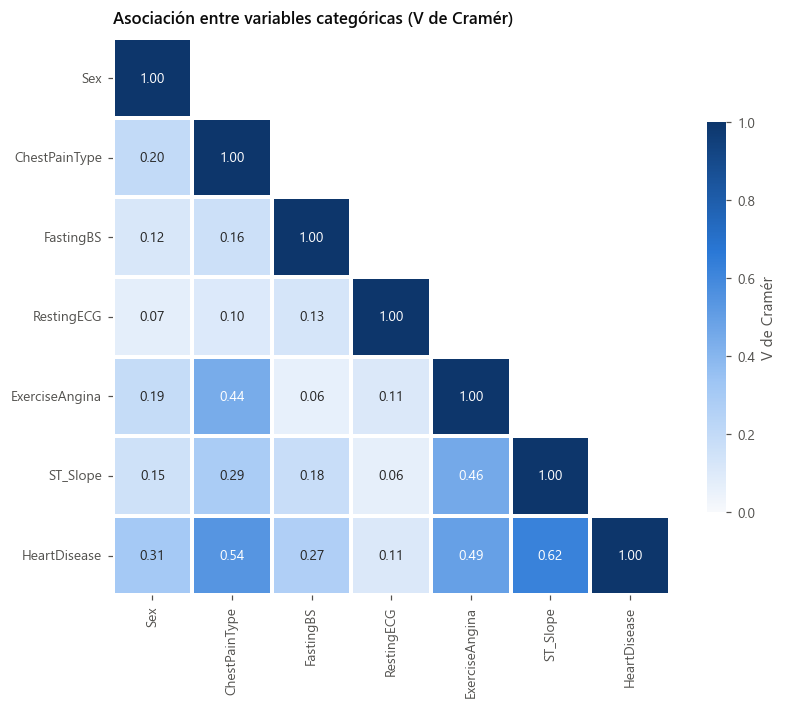

In [22]:
vars_cat_pares = CAT_VARS + [TARGET]
matriz_v = pd.DataFrame(np.eye(len(vars_cat_pares)), index=vars_cat_pares, columns=vars_cat_pares)
filas = []
for i, a in enumerate(vars_cat_pares):
    for b in vars_cat_pares[i + 1:]:
        tabla = pd.crosstab(df[a], df[b])
        chi2, p, _, _ = stats.chi2_contingency(tabla)
        v = cramer_v(tabla)
        matriz_v.loc[a, b] = matriz_v.loc[b, a] = v
        filas.append({"variable_1": a, "variable_2": b, "chi2": chi2, "p_value": p, "V_Cramer": v})

pares_cat = pd.DataFrame(filas).sort_values("V_Cramer", ascending=False)
display(pares_cat.head(8).style.format({"chi2": "{:.1f}", "p_value": "{:.2e}", "V_Cramer": "{:.3f}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(matriz_v, mask=np.triu(np.ones_like(matriz_v, dtype=bool), k=1), cmap=CMAP_SEC, vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9}, linewidths=1.5, linecolor="white", square=True,
            cbar_kws={"shrink": 0.7, "label": "V de Cramér"}, ax=ax)
ax.grid(False)
ax.set_title("Asociación entre variables categóricas (V de Cramér)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_heatmap_cramer.png")
plt.show()

Entre las variables predictoras, la asociación más fuerte es exerciseangina con st_slope (V = 0.46), seguida de chestpaintype con exerciseangina (0.44). Ambas son moderadas, lejos de la redundancia: en Lending Club, grade y sub_grade tenían V = 1.00. Las tres variables describen la respuesta al esfuerzo físico y comparten información, pero cada una aporta algo propio. 

Parte 22. Redundancia entre tipos de variables: razón de correlación η

Para una variable categórica frente a una numérica se usa la razón de correlación η: va de 0 a 1 y mide qué parte de la varianza de la numérica explica la categoría.

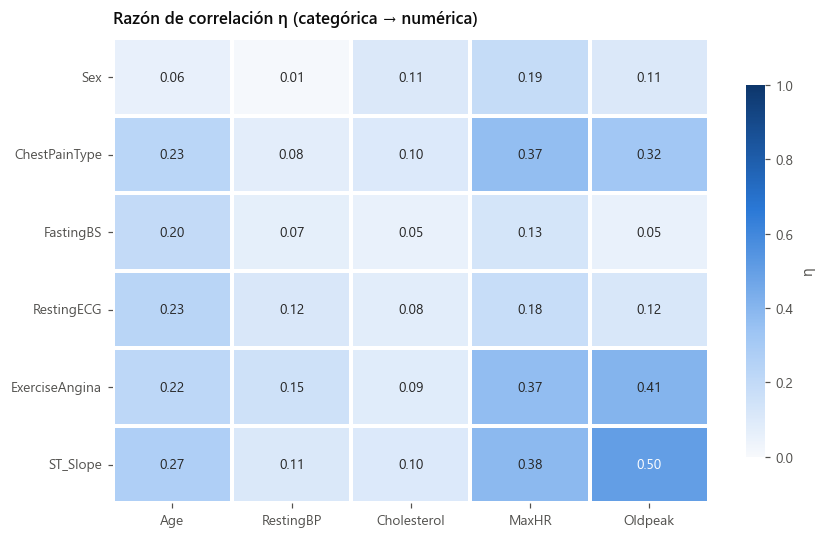

In [23]:
def razon_eta(categorias, valores):
    datos = pd.DataFrame({"c": categorias, "v": valores}).dropna()
    media = datos["v"].mean()
    ss_entre = datos.groupby("c")["v"].apply(lambda g: len(g) * (g.mean() - media) ** 2).sum()
    ss_total = ((datos["v"] - media) ** 2).sum()
    return np.sqrt(ss_entre / ss_total)

matriz_eta = pd.DataFrame({num: {cat: razon_eta(df_eda[cat], df_eda[num]) for cat in CAT_VARS} for num in NUM_VARS})

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(matriz_eta, cmap=CMAP_SEC, vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=1.5, linecolor="white", cbar_kws={"shrink": 0.8, "label": "η"}, ax=ax)
ax.grid(False)
ax.set_title("Razón de correlación η (categórica → numérica)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_heatmap_eta.png")
plt.show()

El valor η más alto es st_slope con oldpeak (η = 0.50). Es esperable, porque ambas miden el segmento ST del electrocardiograma de esfuerzo. Le siguen exerciseangina con oldpeak (0.41) y st_slope, chestpaintype y exerciseangina con maxhr (0.37–0.38). Ninguna relación indica redundancia (η > 0.7), así que no se elimina ninguna variable.

D. Visualizaciones avanzadas

Parte 23. Pairplot / matriz de dispersión

Con 918 pacientes se usan todos los datos (no hace falta muestrear).

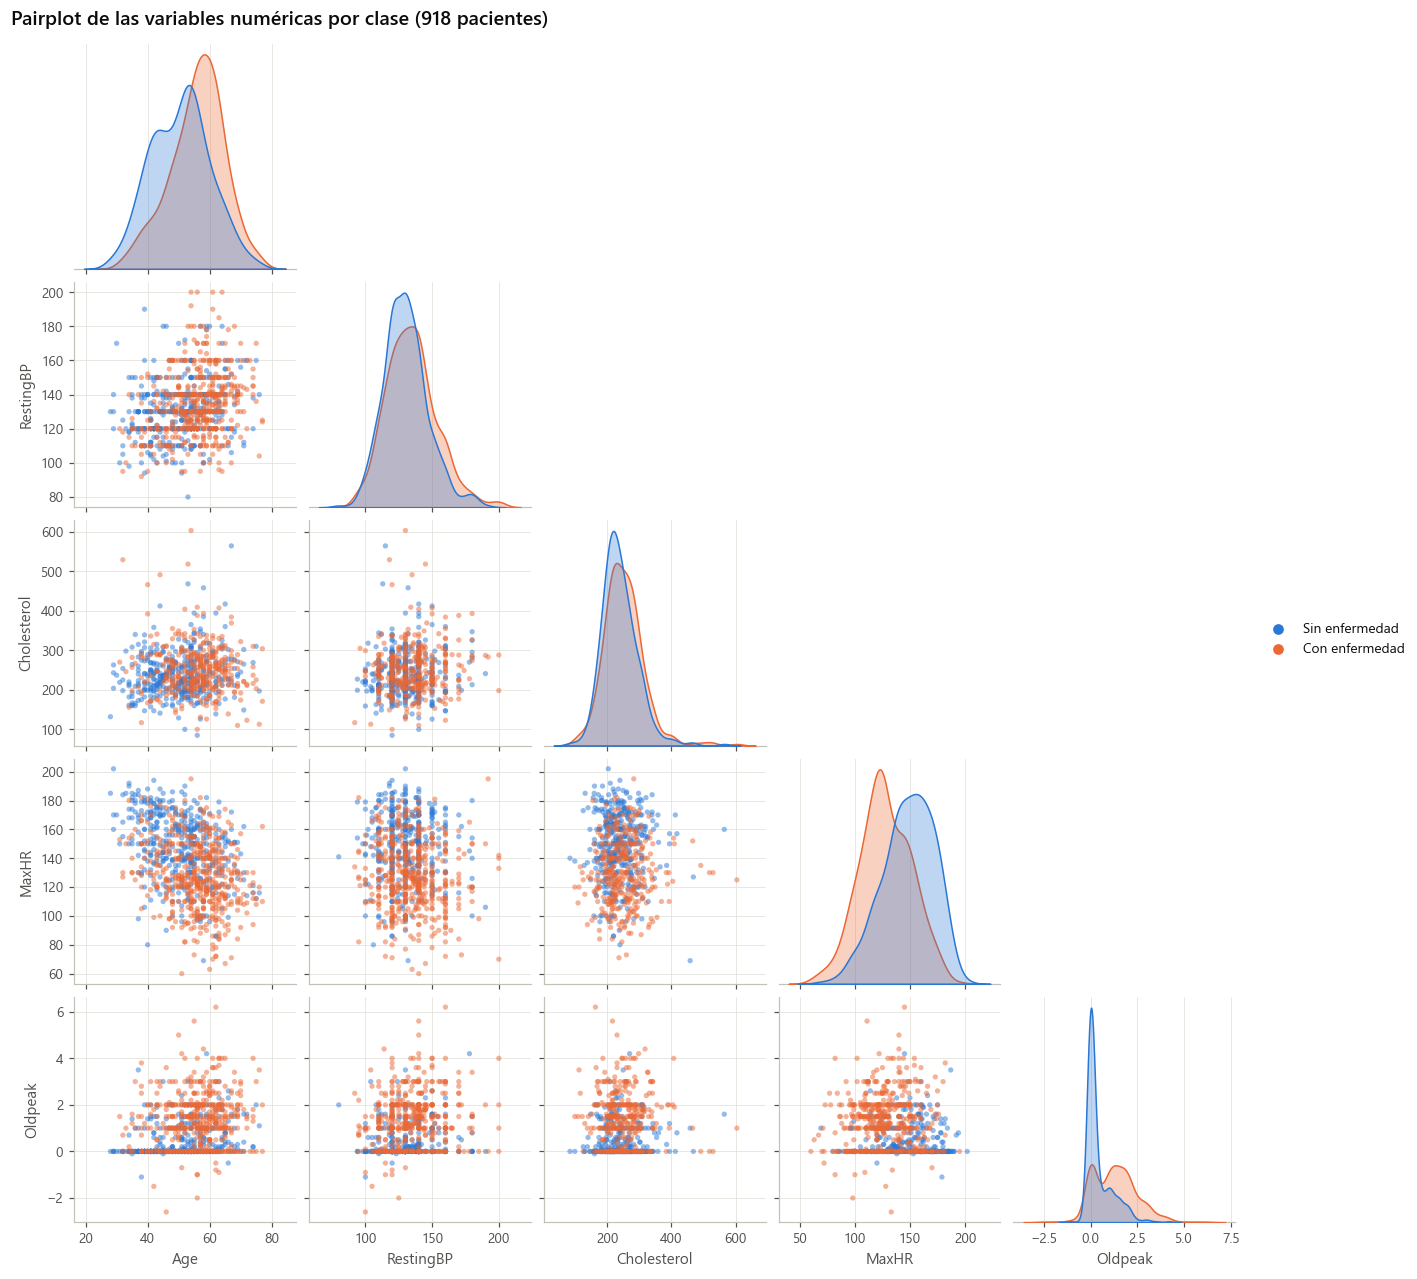

In [24]:
datos_pair = df_eda[NUM_VARS + [TARGET]].copy()
datos_pair["clase"] = datos_pair[TARGET].map(CLASE_NOMBRE)
datos_pair = datos_pair.sort_values(TARGET)

g = sns.pairplot(datos_pair.drop(columns=TARGET), hue="clase", corner=True,
                 palette={CLASE_NOMBRE[k]: CLASE_COLOR[k] for k in (0, 1)},
                 plot_kws=dict(s=12, alpha=0.5, linewidth=0),
                 diag_kws=dict(common_norm=False, fill=True, alpha=0.3), height=2.3)
g._legend.set_title("")
for ax in g.axes.flat:
    if ax is not None:
        ax.grid(True, color=COLOR["rejilla"], linewidth=0.5)
g.fig.suptitle(f"Pairplot de las variables numéricas por clase ({len(datos_pair):,} pacientes)",
               x=0.01, ha="left", y=1.01, fontsize=13, fontweight="semibold")
g.savefig(FIG_DIR / "01_pairplot.png")
plt.show()

En el pairplot, los pacientes con enfermedad se concentran en la zona de maxhr bajo y oldpeak alto. Es la combinación que más separa las clases. No aparecen fronteras no lineales complejas ni grupos aislados. Con cholesterol y restingbp las nubes de puntos de ambas clases se superponen.

E. Valores faltantes (análisis detallado)

Parte 24. ¿Los ceros de cholesterol faltan al azar? (prueba de MCAR)

MCAR significa que el dato falta por puro azar. Si fuera así, la tasa de enfermedad y la distribución de las demás variables deberían ser iguales cuando el colesterol falta y cuando está presente.

Cholesterol faltante vs HeartDisease: χ² = 91.8, p < 0.001, V = 0.319


,n_sin_enfermedad,n_con_enfermedad,n_total,tasa_enfermedad
Cholesterol,,,,
Falta,20,152,172,88.4 %
Presente,390,356,746,47.7 %


,tipo,falta,presente,prueba,p_value,¿rechaza MCAR? (p<0.05)
variable,,,,,,
Age,numérica,mediana 57.5,mediana 54.0,Mann-Whitney,5.20e-06,Sí
RestingBP,numérica,mediana 130.0,mediana 130.0,Mann-Whitney,3.51e-02,Sí
MaxHR,numérica,mediana 120.0,mediana 140.0,Mann-Whitney,1.41e-16,Sí
Oldpeak,numérica,mediana 0.8,mediana 0.5,Mann-Whitney,8.35e-01,No
Sex,categórica,M (94%),M (76%),χ²,3.07e-07,Sí
ChestPainType,categórica,ASY (73%),ASY (50%),χ²,5.39e-09,Sí
FastingBS,categórica,1 (52%),0 (83%),χ²,3.55e-22,Sí
RestingECG,categórica,Normal (62%),Normal (60%),χ²,6.05e-08,Sí
ExerciseAngina,categórica,N (51%),N (62%),χ²,1.59e-02,Sí


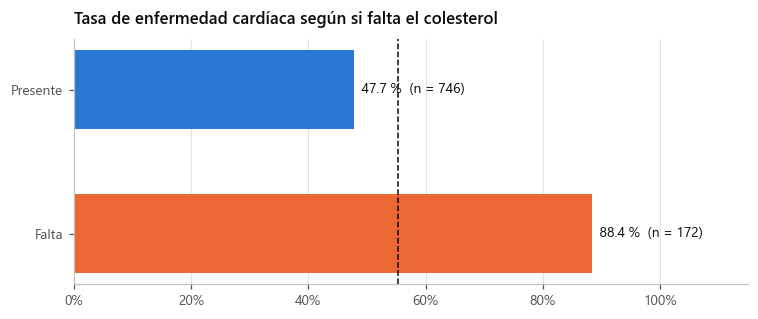

In [25]:
falta_col = df["Cholesterol"].eq(0).map({True: "Falta", False: "Presente"})

# 1) Relación con la variable objetivo
conteos = pd.crosstab(falta_col, df[TARGET])
conteos.columns = ["n_sin_enfermedad", "n_con_enfermedad"]
conteos["n_total"] = conteos.sum(axis=1)
conteos["tasa_enfermedad"] = conteos["n_con_enfermedad"] / conteos["n_total"] * 100
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(falta_col, df[TARGET]))
print(f"Cholesterol faltante vs HeartDisease: χ² = {chi2:.1f}, {fmt_p(p)}, "
      f"V = {cramer_v(pd.crosstab(falta_col, df[TARGET])):.3f}")
display(conteos.style.format({"tasa_enfermedad": "{:.1f} %"}))

# 2) Relación con las demás variables
filas = []
for col in [c for c in NUM_VARS if c != "Cholesterol"]:
    a, b = df_eda.loc[falta_col == "Falta", col].dropna(), df_eda.loc[falta_col == "Presente", col].dropna()
    filas.append({"variable": col, "tipo": "numérica", "falta": f"mediana {a.median():.1f}",
                  "presente": f"mediana {b.median():.1f}", "prueba": "Mann-Whitney",
                  "p_value": stats.mannwhitneyu(a, b).pvalue})
for col in CAT_VARS:
    tabla = pd.crosstab(falta_col, df[col])
    moda_f, moda_p = tabla.loc["Falta"].idxmax(), tabla.loc["Presente"].idxmax()
    filas.append({"variable": col, "tipo": "categórica",
                  "falta": f"{moda_f} ({tabla.loc['Falta', moda_f] / tabla.loc['Falta'].sum():.0%})",
                  "presente": f"{moda_p} ({tabla.loc['Presente', moda_p] / tabla.loc['Presente'].sum():.0%})",
                  "prueba": "χ²", "p_value": stats.chi2_contingency(tabla)[1]})
mcar = pd.DataFrame(filas).set_index("variable")
mcar["¿rechaza MCAR? (p<0.05)"] = np.where(mcar["p_value"] < 0.05, "Sí", "No")
display(mcar.style.format({"p_value": "{:.2e}"}))

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(conteos.index, conteos["tasa_enfermedad"], color=[COLOR["secundario"], COLOR["principal"]], height=0.55)
ax.axvline(TASA_GLOBAL, color=COLOR["texto"], linestyle="--", linewidth=1)
for i, (v, n) in enumerate(zip(conteos["tasa_enfermedad"], conteos["n_total"])):
    ax.text(v, i, f"  {v:.1f} %  (n = {n})", va="center", fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 115)
ax.grid(axis="y", visible=False)
ax.set_title("Tasa de enfermedad cardíaca según si falta el colesterol")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_mcar_cholesterol.png")
plt.show()

Lo que sale es clave para el modelado:

1. Tasa de enfermedad: es del 88.4 % cuando falta el colesterol y del 47.7 % cuando está presente (χ² = 91.8, p < 0.001, V = 0.32). Que el dato falte se asocia con la enfermedad incluso más que sex (V = 0.305).
2. Resto de variables: se rechaza MCAR en 9 de las 10 (todas menos oldpeak). Los pacientes sin colesterol son mayores (mediana 57.5 contra 54), casi todos hombres (94 % contra 76 %), tienen maxhr más baja (120 contra 140) y más glucosa alta en ayunas (fastingbs = 1: 52 % contra 17 %).

Conclusión: los datos no faltan al azar. Este dataset combina 5 bases de datos clínicas: Cleveland, Hungría, Suiza, Long Beach VA y Statlog. Algunos centros no registraron el colesterol y tenían poblaciones con más enfermedad. El mecanismo es MAR, porque depende del hospital de origen.

Qué implica para el modelado:

1. Si se imputa solo con la mediana, se pierde esta señal. Se imputará con la mediana y además se agregará un indicador de faltante (SimpleImputer(add_indicator=True)).
2. El indicador refleja el hospital de origen, no la fisiología del paciente. Es una fuente de sesgo que el modelo en producción podría no encontrar. Se documenta como limitación.
3. La mediana de imputación se calcula solo con el conjunto de entrenamiento, dentro del Pipeline.

Parte 25. Plan de tratamiento por variable

Reglas del preprocesamiento. Todos los pasos con parámetros aprendidos van dentro del Pipeline, para que se ajusten solo con train y no haya fuga:

| Variable | Tipo | Tratamiento | ¿Aprende de los datos? |
|---|---|---|---|
| age, maxhr | Numérica | Escalar | Sí (en el Pipeline) |
| oldpeak | Numérica | Escalar; se conservan ceros y negativos | Sí (en el Pipeline) |
| restingbp | Numérica | 0 → NaN, imputar con la mediana y escalar | Sí (en el Pipeline) |
| cholesterol | Numérica | 0 → NaN, imputar con la mediana, agregar indicador de faltante y escalar | Sí (en el Pipeline) |
| sex, chestpaintype, restingecg, exerciseangina, st_slope | Categórica | OneHotEncoder(handle_unknown="ignore") | Sí (en el Pipeline) |
| fastingbs | Binaria (0/1) | Se deja como está | No |
| heartdisease | Objetivo | Split estratificado 80/20 | — |

Otras decisiones:

1. Outliers: se conservan, porque son clínicamente plausibles (Parte 8).
2. Transformaciones: no se aplican (Parte 11).
3. Variables: no se elimina ninguna por redundancia (Partes 20 a 22).
4. 0 → NaN: reemplazar los ceros es una regla fija que no usa estadísticas del dataset, así que no produce fuga y puede hacerse antes del split. En cambio, la mediana para imputar sí se aprende de los datos y va en el Pipeline.

# Resumen ejecutivo

1. Datos: 918 pacientes, 11 predictores (5 numéricos y 6 categóricos) y la variable objetivo binaria heartdisease. No hay NaN explícitos ni filas duplicadas.
2. Nulos ocultos: el 18.7 % de los valores de cholesterol (172 pacientes) son ceros imposibles, que en realidad son faltantes. No faltan al azar: el 88.4 % de esos pacientes tiene enfermedad, contra el 47.7 % del resto. Se imputan con la mediana más un indicador de faltante, dentro del Pipeline.
3. Clases: 55.3 % con enfermedad y 44.7 % sin ella. El desbalance es leve y se usará un split estratificado.
4. Variables más predictivas:
   1. Categóricas: st_slope (V = 0.62), chestpaintype (V = 0.54) y exerciseangina (V = 0.49).
   2. Numéricas: oldpeak (r = +0.47) y maxhr (r = −0.47).
   3. cholesterol y restingbp son las que menos discriminan.
5. Perfil de alto riesgo: hombre mayor, con dolor de pecho asintomático, angina inducida por ejercicio, pendiente ST plana, oldpeak alto y maxhr baja.
6. Calidad: hay pocos outliers (≤ 3 %) y todos son plausibles, así que se conservan. No hay multicolinealidad (ningún |r| ni V supera 0.7).
7. Consecuencia para el modelado: como hay variables categóricas y faltantes, el preprocesamiento necesita un ColumnTransformer con imputación, One-Hot y escalado. Todo va dentro del Pipeline, para que la validación cruzada de GridSearchCV no tenga fuga

# Preprocesamiento



Los modelos de scikit-learn solo aceptan números y no aceptan valores faltantes. Por eso hay que convertir las variables categóricas en columnas numéricas, llenar los faltantes y poner las variables numéricas en una escala comparable.

Lo más importante es el orden. Primero se separan los datos de entrenamiento y de prueba, y solo después se calculan las medianas, los mínimos y los máximos, usando únicamente los de entrenamiento. Así el conjunto de prueba se comporta como un grupo de pacientes nuevos que el modelo nunca vio.

Parte 26. Librerías de modelado

In [26]:
import os
# joblib no puede contar los núcleos físicos en este Windows y lanza un aviso; se le indica cuántos usar
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, (os.cpu_count() or 2) // 2))

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

print(f"scikit-learn {sklearn.__version__}")

scikit-learn 1.3.0


Parte 27. Matriz de variables, objetivo y ceros imposibles

Se separan las variables (X) del objetivo (y). Los ceros de restingbp y cholesterol se convierten en NaN antes del split. Esto no produce fuga porque es una regla fija,porque estos valors no son poisbles como se mencionó, que no usa ninguna estadística calculada con los datos. Lo que sí se aprende de los datos, como la mediana para imputar, se deja para el Pipeline.

In [27]:
X = df.drop(columns=TARGET).copy()
y = df[TARGET].copy()
X[CEROS_IMPOSIBLES] = X[CEROS_IMPOSIBLES].replace(0, np.nan)

print(f"X: {X.shape[0]} filas x {X.shape[1]} columnas | y: {y.shape[0]} valores")
print("Nulos en X después de marcar los ceros imposibles:")
display(X.isna().sum()[lambda s: s > 0].to_frame("n_nulos"))

X: 918 filas x 11 columnas | y: 918 valores
Nulos en X después de marcar los ceros imposibles:


,n_nulos
RestingBP,1
Cholesterol,172


Parte 28. División train/test antes de cualquier ajuste

El conjunto de prueba se separa antes de calcular cualquier estadística. Se usa un split estratificado 80/20, para que las dos partes conserven la proporción de enfermos (Parte 14). 

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

particion = pd.DataFrame({
    "n": [len(y), len(y_train), len(y_test)],
    "pct_con_enfermedad": [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
    "nulos_cholesterol": [X["Cholesterol"].isna().sum(), X_train["Cholesterol"].isna().sum(),
                          X_test["Cholesterol"].isna().sum()],
}, index=["completo", "train", "test"])
display(particion.style.format({"pct_con_enfermedad": "{:.2f} %"}))

# Validación cruzada estratificada y reproducible para todas las búsquedas
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

,n,pct_con_enfermedad,nulos_cholesterol
completo,918,55.34 %,172
train,734,55.31 %,129
test,184,55.43 %,43


Parte 29. Preprocesador con ColumnTransformer

Se aplica el plan de la Parte 25. Cada grupo de columnas recibe su propio tratamiento:

| Grupo | Columnas | Tratamiento |
|---|---|---|
| num | age, maxhr, oldpeak | MinMaxScaler |
| num_nulos | restingbp, cholesterol | Imputación con la mediana + indicador de faltante, y después MinMaxScaler |
| cat | sex, chestpaintype, restingecg, exerciseangina, st_slope | OneHotEncoder |
| bin | fastingbs | Sin cambios (ya es 0/1) |

Se usa MinMaxScaler. La función recibe columnas numéricas adicionales para poder agregar la variable fugada en la Parte 30.

In [29]:
COLS_ESCALAR = ["Age", "MaxHR", "Oldpeak"]
COLS_IMPUTAR = ["RestingBP", "Cholesterol"]
COLS_ONEHOT = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
COLS_BINARIAS = ["FastingBS"]


def crear_preprocesador(extra_num=()):
    """Imputa, escala y codifica. Todos los parámetros se aprenden solo con los datos que recibe en fit."""
    return ColumnTransformer([
        ("num", MinMaxScaler(), COLS_ESCALAR + list(extra_num)),
        ("num_nulos", Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)),
                                ("escalar", MinMaxScaler())]), COLS_IMPUTAR),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_ONEHOT),
        ("bin", "passthrough", COLS_BINARIAS),
    ], verbose_feature_names_out=False)


prep = crear_preprocesador().fit(X_train)            # se ajusta SOLO con train
X_train_t = pd.DataFrame(prep.transform(X_train), columns=prep.get_feature_names_out(), index=X_train.index)

print(f"Columnas antes: {X_train.shape[1]} -> después del preprocesamiento: {X_train_t.shape[1]}")
print(list(X_train_t.columns))
display(X_train_t.head())

# Los parámetros aprendidos vienen solo de train (comparación con los del dataset completo)
aprendido = pd.DataFrame({
    "mediana_train (usada)": prep.named_transformers_["num_nulos"]["imputar"].statistics_,
    "mediana_dataset_completo": X[COLS_IMPUTAR].median().values,
}, index=COLS_IMPUTAR)
display(aprendido)

Columnas antes: 11 -> después del preprocesamiento: 21
['Age', 'MaxHR', 'Oldpeak', 'RestingBP', 'Cholesterol', 'missingindicator_Cholesterol', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'FastingBS']


,Age,MaxHR,Oldpeak,RestingBP,Cholesterol,missingindicator_Cholesterol,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,FastingBS
485,0.7083,0.4789,0.4634,0.4352,0.2548,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
486,0.5417,0.8451,0.3659,0.1667,0.2490,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
117,0.6250,0.4930,0.5000,0.3519,0.4884,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
361,0.3750,0.4507,0.3171,0.6296,0.2954,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
296,0.4375,0.5563,0.4024,0.4907,0.2954,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000


,mediana_train (usada),mediana_dataset_completo
RestingBP,130.0000,130.0000
Cholesterol,238.0000,237.0000


Lo que sale: las 11 columnas originales pasan a 21. Las 5 categóricas se convierten en 15 columnas One-Hot, y se agrega missingindicator_Cholesterol, que vale 1 cuando faltaba el colesterol.

La mediana que usa el imputador para cholesterol es 238 mg/dl, calculada solo con train. La del dataset completo es 237. La diferencia es pequeña, pero muestra que el preprocesador no vio los datos de prueba.

No aparece un indicador para restingbp. SimpleImputer solo crea el indicador para las columnas que tienen nulos en train, y el único cero de restingbp quedó en test. En test ese valor se imputa con la mediana de train (130), que es justo lo que pasaría con un paciente nuevo en producción.

# Detección de data leakage



La fuga ocurre cuando el modelo tiene acceso durante el entrenamiento a información que no tendría en la vida real, por ejemplo datos del conjunto de prueba o una variable que contiene la respuesta. El resultado es un modelo que parece excelente en la evaluación pero falla con pacientes nuevos.


Parte 30. Ejemplo del profesor adaptado al dataset

Igual que en el enunciado, los dos flujos tienen la variable artificial leaky_feature, que es el objetivo más un ruido muy pequeño.

In [30]:
X_fuga = X.copy()
np.random.seed(0)
X_fuga["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

# --- Ejemplo con fuga de datos: el preprocesamiento ve el dataset completo antes del split ---
X_fuga_enc = pd.get_dummies(X_fuga, columns=COLS_ONEHOT, dtype=float)
X_fuga_enc = X_fuga_enc.fillna(X_fuga_enc.median())             # mediana calculada con train + test
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_fuga_enc)                     # mínimo y máximo calculados con train + test
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_scaled, y, test_size=0.2, stratify=y,
                                                            random_state=SEED)
grid_l = GridSearchCV(SVC(probability=True, random_state=SEED),
                      param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}, cv=5, scoring="roc_auc")
grid_l.fit(X_train_l, y_train_l)
auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])

# --- Flujo correcto: split primero, preprocesamiento dentro del Pipeline ---
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fuga, y, test_size=0.2, stratify=y,
                                                            random_state=SEED)
pipe = Pipeline([("prep", crear_preprocesador(extra_num=["leaky_feature"])),
                 ("svc", SVC(probability=True, random_state=SEED))])
param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train_f, y_train_f)
auc = roc_auc_score(y_test_f, grid.predict_proba(X_test_f)[:, 1])

print(f"AUC con fuga: {auc_l:.3f}")
print(f"AUC sin fuga: {auc:.3f}")

AUC con fuga: 1.000
AUC sin fuga: 1.000


Los dos flujos dan AUC = 1.000. Esto muestra algo que el ejemplo del enunciado no dice explícitamente: el Pipeline no protege contra la fuga del objetivo. leaky_feature es prácticamente la respuesta, así que cualquier modelo que la reciba acierta siempre, sin importar si el escalado se hizo antes o después del split. Un AUC perfecto en un problema clínico real es, casi siempre, una señal de fuga y no un buen modelo. Para ver qué corrige el Pipeline hay que separar las dos fugas, como se hace en la Parte 31.

Parte 31. Los dos tipos de fuga por separado

En el ejemplo del enunciado se mezclan dos fugas distintas:

1. Fuga del objetivo (target leakage): una variable que contiene la respuesta. El Pipeline no la corrige, porque el problema está en los datos y no en el orden de los pasos.
2. Fuga de preprocesamiento: los parámetros del escalador o del imputador se calculan con datos de prueba. Esto es lo que el Pipeline sí evita.

Para ver el efecto de cada una se prueban las 4 combinaciones con el mismo SVC y la misma búsqueda de hiperparámetros.

In [31]:
def escenario_fuga(X_base, preprocesar_antes_del_split):
    """Entrena un SVC con GridSearchCV y devuelve el AUC de validación cruzada y el de test."""
    extra = ["leaky_feature"] if "leaky_feature" in X_base.columns else []
    grilla = {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}
    if preprocesar_antes_del_split:
        X_base = crear_preprocesador(extra).fit_transform(X_base)       # ajuste con train + test
        modelo, grilla = SVC(probability=True, random_state=SEED), grilla
    else:
        modelo = Pipeline([("prep", crear_preprocesador(extra)), ("svc", SVC(probability=True, random_state=SEED))])
        grilla = {f"svc__{k}": v for k, v in grilla.items()}
    Xtr, Xte, ytr, yte = train_test_split(X_base, y, test_size=0.2, stratify=y, random_state=SEED)
    g = GridSearchCV(modelo, grilla, cv=CV, scoring="roc_auc").fit(Xtr, ytr)
    return g.best_score_, roc_auc_score(yte, g.predict_proba(Xte)[:, 1])


filas = []
for nombre_x, X_base in [("Sin leaky_feature", X), ("Con leaky_feature", X_fuga)]:
    for antes in (True, False):
        auc_cv, auc_test = escenario_fuga(X_base, antes)
        filas.append({"variables": nombre_x,
                      "preprocesamiento": "Antes del split (con fuga)" if antes else "Dentro del Pipeline (sin fuga)",
                      "AUC_CV": auc_cv, "AUC_test": auc_test})

tabla_fuga = pd.DataFrame(filas).set_index(["variables", "preprocesamiento"])
display(tabla_fuga.style.format("{:.4f}"))

1. Con leaky_feature: AUC = 1.000 en las dos variantes. La fuga del objetivo domina todo.
2. Sin leaky_feature: con el preprocesamiento antes del split, AUC CV = 0.9263 y AUC test = 0.9370. Dentro del Pipeline, AUC CV = 0.9269 y AUC test = 0.9374.

En este dataset la fuga de preprocesamiento casi no cambia el resultado: la diferencia está en el cuarto decimal. Para confirmar que no es cosa de una sola partición, la Parte 32 repite el experimento 50 veces.

Parte 32. ¿Cuánto infla el preprocesamiento antes del split? (50 repeticiones)

Una sola partición puede dar una diferencia por azar. Se repite el experimento con 50 seeds distintas y una regresión logística, comparando el AUC de test con el preprocesamiento ajustado antes del split y dentro del Pipeline.

In [32]:
filas = []
for semilla in range(50):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=semilla)

    # Con fuga: el preprocesador se ajusta con train + test
    prep_fuga = crear_preprocesador().fit(X)
    lr = LogisticRegression(max_iter=2000).fit(prep_fuga.transform(Xtr), ytr)
    auc_fuga = roc_auc_score(yte, lr.predict_proba(prep_fuga.transform(Xte))[:, 1])

    # Sin fuga: el preprocesador se ajusta solo con train (Pipeline)
    pipe_ok = Pipeline([("prep", crear_preprocesador()), ("clf", LogisticRegression(max_iter=2000))]).fit(Xtr, ytr)
    auc_ok = roc_auc_score(yte, pipe_ok.predict_proba(Xte)[:, 1])
    filas.append({"semilla": semilla, "AUC_con_fuga": auc_fuga, "AUC_sin_fuga": auc_ok})

repeticiones = pd.DataFrame(filas)
repeticiones["diferencia"] = repeticiones["AUC_con_fuga"] - repeticiones["AUC_sin_fuga"]
display(repeticiones[["AUC_con_fuga", "AUC_sin_fuga", "diferencia"]].describe().T
        .style.format("{:.5f}"))
w_stat, p_w = stats.wilcoxon(repeticiones["AUC_con_fuga"], repeticiones["AUC_sin_fuga"])
print(f"Wilcoxon pareado: {fmt_p(p_w)}")
print(f"Repeticiones donde la fuga da mayor AUC: {(repeticiones['diferencia'] > 0).sum()} de 50")

,count,mean,std,min,25%,50%,75%,max
AUC_con_fuga,50.00000,0.92620,0.01525,0.88128,0.91625,0.92533,0.93723,0.96031
AUC_sin_fuga,50.00000,0.92625,0.01527,0.88140,0.91625,0.92545,0.93720,0.96031
diferencia,50.00000,-0.00005,0.00020,-0.00072,-0.00012,0.00000,0.00009,0.00036


Wilcoxon pareado: p = 0.189
Repeticiones donde la fuga da mayor AUC: 13 de 50


En 50 particiones distintas, la diferencia media es −0.00005, y el preprocesamiento con fuga solo da mayor AUC en 13 de las 50. La prueba de Wilcoxon pareada no encuentra diferencia (p = 0.189).

El efecto es nulo porque los parámetros que aprende este preprocesador son muy estables. El mínimo y el máximo de MinMaxScaler y la mediana del imputador casi no cambian entre 734 y 918 pacientes, y el OneHotEncoder solo aprende la lista de categorías, que es la misma en train y en test. Aun así, ajustar antes del split sigue siendo un error metodológico:

1. La evaluación deja de simular lo que pasa en producción, donde el paciente nuevo no estaba cuando se ajustó el escalador.
2. Si el preprocesamiento aprende más de los datos, el sesgo crece. Pasa con la codificación por la media del objetivo, la selección de variables, el sobremuestreo con SMOTE o PCA. La Parte 33 muestra un ejemplo.
3. Ponerlo dentro del Pipeline no cuesta nada y lo garantiza en cada fold de GridSearchCV.

Parte 33. Fuga por selección de variables (un caso donde la fuga sí engaña)

Se construye un caso extremo: 5,000 variables de ruido puro, generadas al azar y sin ninguna relación con heartdisease. Un modelo honesto debería dar AUC ≈ 0.5, que es lo mismo que adivinar.

1. Con fuga: se eligen las 20 variables más relacionadas con y usando todo el dataset, y después se hace la validación cruzada.
2. Sin fuga: la selección va dentro del Pipeline, así que en cada fold se elige solo con los datos de entrenamiento de ese fold.

In [33]:
rng = np.random.default_rng(SEED)
X_ruido = rng.normal(size=(len(y), 5000))

# Con fuga: SelectKBest ve todas las filas (incluidas las que después serán de validación)
seleccion = SelectKBest(f_classif, k=20).fit(X_ruido, y)
auc_sel_fuga = cross_val_score(LogisticRegression(max_iter=2000), seleccion.transform(X_ruido), y,
                               cv=CV, scoring="roc_auc")

# Sin fuga: la selección se repite dentro de cada fold
pipe_sel = Pipeline([("seleccion", SelectKBest(f_classif, k=20)), ("clf", LogisticRegression(max_iter=2000))])
auc_sel_ok = cross_val_score(pipe_sel, X_ruido, y, cv=CV, scoring="roc_auc")

print(f"AUC CV con fuga (selección antes de la CV) : {auc_sel_fuga.mean():.3f} ± {auc_sel_fuga.std():.3f}")
print(f"AUC CV sin fuga (selección en el Pipeline) : {auc_sel_ok.mean():.3f} ± {auc_sel_ok.std():.3f}")

AUC CV con fuga (selección antes de la CV) : 0.716 ± 0.021
AUC CV sin fuga (selección en el Pipeline) : 0.531 ± 0.045


Aquí la fuga sí engaña. Con variables que son ruido puro, la validación cruzada con fuga reporta AUC = 0.716 ± 0.021, como si el modelo tuviera capacidad predictiva. Con la selección dentro del Pipeline, el AUC baja a 0.531 ± 0.045, prácticamente el azar, que es la respuesta correcta.

La razón es que, entre 5,000 variables aleatorias, siempre habrá unas 20 que por casualidad se relacionan con y en esas 918 filas. Si se eligen mirando todas las filas, también se eligen mirando las de validación, y el modelo parece aprender un patrón que no existe.

Parte 34. Resumen gráfico de los experimentos de fuga

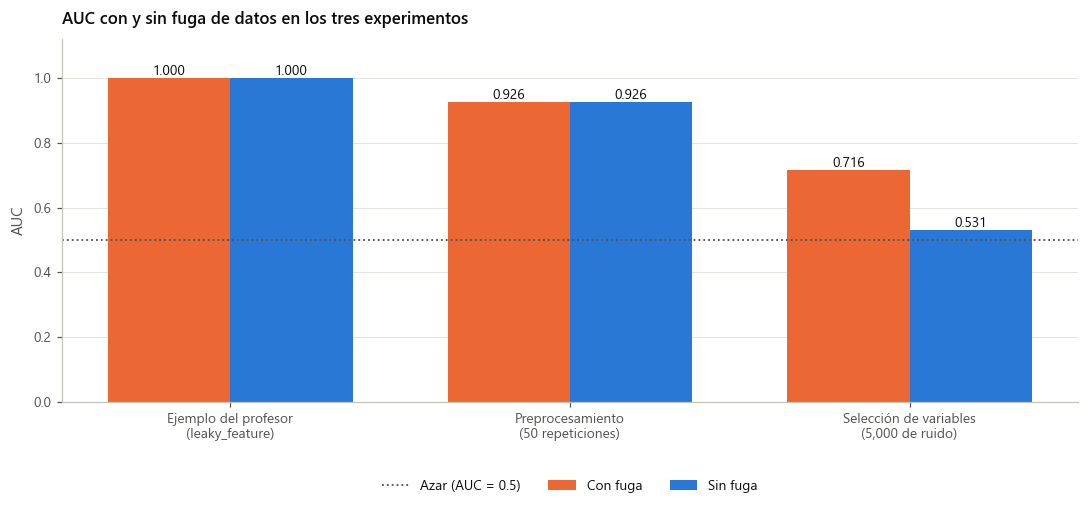

In [34]:
resumen_fuga = pd.DataFrame({
    "experimento": ["Ejemplo del profesor\n(leaky_feature)", "Ejemplo del profesor\n(leaky_feature)",
                    "Preprocesamiento\n(50 repeticiones)", "Preprocesamiento\n(50 repeticiones)",
                    "Selección de variables\n(5,000 de ruido)", "Selección de variables\n(5,000 de ruido)"],
    "flujo": ["Con fuga", "Sin fuga"] * 3,
    "AUC": [auc_l, auc, repeticiones["AUC_con_fuga"].mean(), repeticiones["AUC_sin_fuga"].mean(),
            auc_sel_fuga.mean(), auc_sel_ok.mean()],
})

fig, ax = plt.subplots(figsize=(10, 4.8))
posiciones = np.arange(3)
for i, (flujo, color) in enumerate([("Con fuga", COLOR["secundario"]), ("Sin fuga", COLOR["principal"])]):
    valores = resumen_fuga.loc[resumen_fuga["flujo"] == flujo, "AUC"].values
    barras = ax.bar(posiciones + (i - 0.5) * 0.36, valores, width=0.36, color=color, label=flujo)
    for barra, v in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0.5, color=COLOR["texto_2"], linestyle=":", linewidth=1.2, label="Azar (AUC = 0.5)")
ax.set_xticks(posiciones, resumen_fuga["experimento"].unique())
ax.set_ylim(0, 1.12)
ax.set_ylabel("AUC")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
ax.set_title("AUC con y sin fuga de datos en los tres experimentos")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_resumen_fuga.png")
plt.show()

# Modelado y comparación (flujo sin fuga)

Qué se hace y por qué

Con el flujo sin fuga ya definido, se entrenan varios modelos con el mismo preprocesamiento y la misma validación cruzada, y se comparan con AUC y Accuracy.

Se prueban varios porque no existe un modelo que sea el mejor en todos los problemas. Unos capturan relaciones lineales, como la regresión logística, y otros relaciones no lineales, como SVC, KNN y los modelos de árboles. GridSearchCV busca los mejores hiperparámetros de cada uno. El Pipeline garantiza que, en cada fold, el preprocesamiento se ajuste solo con los datos de entrenamiento de ese fold.

Parte 35. Funciones reutilizables

Se encapsula la lógica de entrenamiento y evaluación en funciones, como sugiere el enunciado. train_pipeline sigue la firma del ejemplo del profesor, pero usa el preprocesador de la Parte 29 en lugar de un MinMaxScaler solo, porque el dataset tiene categóricas y nulos.

In [35]:
def construir_pipeline(modelo):
    """Preprocesador (Parte 29) + clasificador en un solo objeto."""
    return Pipeline([("prep", crear_preprocesador()), ("clf", modelo)])


def train_pipeline(X_train, y_train, model, param_grid, cv=CV, scoring="roc_auc"):
    """Busca los mejores hiperparámetros con validación cruzada. El preprocesamiento se reajusta en cada fold."""
    grid = GridSearchCV(construir_pipeline(model), param_grid, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=True)
    grid.fit(X_train, y_train)
    return grid


def evaluar_modelo(grid, X_test, y_test):
    """Métricas en test y resumen de la validación cruzada del mejor modelo."""
    proba = grid.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    i = grid.best_index_
    folds = [grid.cv_results_[f"split{k}_test_score"][i] for k in range(grid.n_splits_)]
    return {
        "AUC_test": roc_auc_score(y_test, proba),
        "Accuracy_test": accuracy_score(y_test, pred),
        "Precision_test": precision_score(y_test, pred),
        "Recall_test": recall_score(y_test, pred),
        "Especificidad_test": recall_score(y_test, pred, pos_label=0),
        "F1_test": f1_score(y_test, pred),
        "AUC_CV_media": grid.cv_results_["mean_test_score"][i],
        "AUC_CV_std": grid.cv_results_["std_test_score"][i],
        "AUC_train_CV": grid.cv_results_["mean_train_score"][i],
        "AUC_folds": folds,
        "mejores_parametros": {k.replace("clf__", ""): v for k, v in grid.best_params_.items()},
        "proba_test": proba,
    }


def comparar_modelos(modelos, X_train, y_train, X_test, y_test):
    """Entrena y evalúa cada modelo. Devuelve los GridSearchCV ajustados y el ranking por AUC de test."""
    ajustados, filas = {}, []
    for nombre, (modelo, grilla) in modelos.items():
        t0 = time.time()
        grid = train_pipeline(X_train, y_train, modelo, grilla)
        segundos = time.time() - t0
        resultado = evaluar_modelo(grid, X_test, y_test)
        ajustados[nombre] = grid
        n_comb = len(grid.cv_results_["params"])
        filas.append({"modelo": nombre, **resultado, "combinaciones": n_comb, "tiempo_s": segundos})
        print(f"{nombre:20s} {n_comb:4d} combinaciones x {grid.n_splits_} folds  ·  {segundos:6.1f} s  ·  "
              f"AUC CV = {resultado['AUC_CV_media']:.4f}  ·  AUC test = {resultado['AUC_test']:.4f}")
    ranking = (pd.DataFrame(filas).set_index("modelo")
               .sort_values(["AUC_test", "AUC_CV_media"], ascending=False))
    ranking.insert(0, "puesto", range(1, len(ranking) + 1))
    return ajustados, ranking

Parte 36. Modelos y espacios de búsqueda

Se implementan los modelos vistos en el curso: el SVC del enunciado, los cuatro recomendados (LogisticRegression, RandomForestClassifier, KNeighborsClassifier y GradientBoostingClassifier) y dos más, un árbol de decisión y Naive Bayes gaussiano. Las grillas son pequeñas porque el dataset tiene solo 734 filas de entrenamiento.

In [36]:
MODELOS = {
    "SVC": (SVC(probability=True, random_state=SEED),
            {"clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", 0.01, 0.1], "clf__kernel": ["rbf"]}),
    "LogisticRegression": (LogisticRegression(max_iter=5000, solver="liblinear", random_state=SEED),
                           {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}),
    "KNN": (KNeighborsClassifier(),
            {"clf__n_neighbors": [5, 11, 21, 31, 51, 71, 101], "clf__weights": ["uniform", "distance"], "clf__p": [1, 2]}),
    "DecisionTree": (DecisionTreeClassifier(random_state=SEED),
                     {"clf__max_depth": [3, 4, 5, 7, None], "clf__min_samples_leaf": [1, 5, 10, 20],
                      "clf__criterion": ["gini", "entropy"]}),
    "RandomForest": (RandomForestClassifier(random_state=SEED, n_jobs=1),
                     {"clf__n_estimators": [300], "clf__max_depth": [None, 5, 10],
                      "clf__min_samples_leaf": [1, 3, 5], "clf__max_features": ["sqrt", 0.5]}),
    "GradientBoosting": (GradientBoostingClassifier(random_state=SEED),
                         {"clf__n_estimators": [100, 300], "clf__learning_rate": [0.01, 0.03, 0.1],
                          "clf__max_depth": [2, 3], "clf__subsample": [0.8, 1.0]}),
    "GaussianNB": (GaussianNB(), {"clf__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]}),
}

pd.DataFrame([{"modelo": n, "hiperparámetros": ", ".join(k.replace("clf__", "") for k in g),
               "combinaciones": int(np.prod([len(v) for v in g.values()]))} for n, (_, g) in MODELOS.items()]
            ).set_index("modelo")

,hiperparámetros,combinaciones
modelo,,
SVC,"C, gamma, kernel",12
LogisticRegression,"C, penalty",8
KNN,"n_neighbors, weights, p",28
DecisionTree,"max_depth, min_samples_leaf, criterion",40
RandomForest,"n_estimators, max_depth, min_samples_leaf, max...",18
GradientBoosting,"n_estimators, learning_rate, max_depth, subsample",24
GaussianNB,var_smoothing,4


Parte 37. Entrenamiento con GridSearchCV

In [37]:
t_total = time.time()
grids, ranking = comparar_modelos(MODELOS, X_train, y_train, X_test, y_test)
print(f"\nTiempo total: {time.time() - t_total:.1f} s")

SVC                    12 combinaciones x 5 folds  ·     2.1 s  ·  AUC CV = 0.9269  ·  AUC test = 0.9374
LogisticRegression      8 combinaciones x 5 folds  ·     0.2 s  ·  AUC CV = 0.9292  ·  AUC test = 0.9301


KNN                    28 combinaciones x 5 folds  ·     0.7 s  ·  AUC CV = 0.9273  ·  AUC test = 0.9401


DecisionTree           40 combinaciones x 5 folds  ·     0.8 s  ·  AUC CV = 0.9091  ·  AUC test = 0.8977


RandomForest           18 combinaciones x 5 folds  ·     7.0 s  ·  AUC CV = 0.9343  ·  AUC test = 0.9341


GradientBoosting       24 combinaciones x 5 folds  ·     5.4 s  ·  AUC CV = 0.9329  ·  AUC test = 0.9311
GaussianNB              4 combinaciones x 5 folds  ·     0.1 s  ·  AUC CV = 0.9152  ·  AUC test = 0.9102

Tiempo total: 16.4 s


Parte 38. Ranking comparativo (AUC y Accuracy)

In [38]:
ranking["brecha_train_CV"] = ranking["AUC_train_CV"] - ranking["AUC_CV_media"]
ranking["puesto_accuracy"] = ranking["Accuracy_test"].rank(ascending=False, method="min").astype(int)

cols_ranking = ["puesto", "AUC_test", "Accuracy_test", "puesto_accuracy", "AUC_CV_media", "AUC_CV_std",
                "brecha_train_CV", "Precision_test", "Recall_test", "Especificidad_test", "F1_test", "tiempo_s"]
display(ranking[cols_ranking].style
        .format({c: "{:.4f}" for c in cols_ranking if c not in ("puesto", "puesto_accuracy", "tiempo_s")}
                | {"tiempo_s": "{:.1f}"})
        .background_gradient(subset=["AUC_test", "Accuracy_test"], cmap=CMAP_SEC))

print("Mejores hiperparámetros:")
for nombre, fila in ranking.iterrows():
    print(f"  {fila['puesto']}. {nombre:20s} {fila['mejores_parametros']}")

# Comparación directa con el SVC del enunciado
svc_auc = ranking.loc["SVC", "AUC_test"]
print("\nDiferencia de AUC de test frente al SVC:")
display((ranking["AUC_test"] - svc_auc).rename("dif_vs_SVC").to_frame().style.format("{:+.4f}"))

,puesto,AUC_test,Accuracy_test,puesto_accuracy,AUC_CV_media,AUC_CV_std,brecha_train_CV,Precision_test,Recall_test,Especificidad_test,F1_test,tiempo_s
modelo,,,,,,,,,,,,
KNN,1,0.9401,0.9130,1,0.9273,0.0324,0.0727,0.9057,0.9412,0.8780,0.9231,0.7
SVC,2,0.9374,0.8804,4,0.9269,0.0360,0.0147,0.8704,0.9216,0.8293,0.8952,2.1
RandomForest,3,0.9341,0.8913,2,0.9343,0.0265,0.0391,0.8727,0.9412,0.8293,0.9057,7.0
GradientBoosting,4,0.9311,0.8804,4,0.9329,0.0245,0.0381,0.8774,0.9118,0.8415,0.8942,5.4
LogisticRegression,5,0.9301,0.8804,4,0.9292,0.0370,0.0070,0.8774,0.9118,0.8415,0.8942,0.2
GaussianNB,6,0.9102,0.8859,3,0.9152,0.0437,0.0058,0.8857,0.9118,0.8537,0.8986,0.1
DecisionTree,7,0.8977,0.8315,7,0.9091,0.0292,0.0245,0.8660,0.8235,0.8415,0.8442,0.8


Mejores hiperparámetros:
  1. KNN                  {'n_neighbors': 51, 'p': 2, 'weights': 'distance'}
  2. SVC                  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
  3. RandomForest         {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
  4. GradientBoosting     {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  5. LogisticRegression   {'C': 1, 'penalty': 'l2'}
  6. GaussianNB           {'var_smoothing': 0.001}
  7. DecisionTree         {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 20}

Diferencia de AUC de test frente al SVC:


,dif_vs_SVC
modelo,
KNN,+0.0027
SVC,+0.0000
RandomForest,-0.0032
GradientBoosting,-0.0062
LogisticRegression,-0.0073
GaussianNB,-0.0271
DecisionTree,-0.0397


Ranking por AUC de test:

1. KNN: AUC = 0.940 y Accuracy = 0.913. Es el primero en las dos métricas.
2. SVC: AUC = 0.937 y Accuracy = 0.880.
3. RandomForest: AUC = 0.934 y Accuracy = 0.891.
4. GradientBoosting: AUC = 0.931 y Accuracy = 0.880.
5. LogisticRegression: AUC = 0.930 y Accuracy = 0.880.
6. GaussianNB: AUC = 0.910 y Accuracy = 0.886.
7. DecisionTree: AUC = 0.898 y Accuracy = 0.832.

Frente al SVC del enunciado, solo KNN lo supera (+0.003). RandomForest, GradientBoosting y la regresión logística quedan a menos de 0.008. Naive Bayes y el árbol de decisión quedan claramente por debajo, con −0.027 y −0.040.


1. Las diferencias entre los 5 primeros son de menos de 0.01 de AUC. Son mucho menores que la variación entre folds (AUC_CV_std ≈ 0.025–0.037). Con solo 184 pacientes de prueba, un par de pacientes clasificados distinto cambia el orden. En la práctica, los 5 primeros empatan.
2. Por AUC de validación cruzada, que usa 734 pacientes en lugar de 184, el orden cambia: RandomForest es el primero (0.934), seguido de GradientBoosting (0.933) y la regresión logística (0.929). KNN y SVC quedan con 0.927.
3. KNN eligió weights = distance, así que en train cada punto es su propio vecino y memoriza los datos. Eso explica su brecha train–CV de 0.073, la mayor de todos. La regresión logística y Naive Bayes casi no tienen brecha (menos de 0.01).
4. Todos tienen sensibilidad (recall) alta, entre 0.91 y 0.94, salvo el árbol (0.82). La especificidad es más baja y varía más: KNN llega a 0.878 y SVC y RandomForest se quedan en 0.829. Como se dijo en la Parte 14, los falsos positivos también importan, así que la especificidad debería pesar en la elección.

El modelo trivial tendría 55.4 % de accuracy, y todos los modelos lo superan por más de 27 puntos, por lo que SÍ se consiguió un amejora. 

Parte 39. Gráficas comparativas

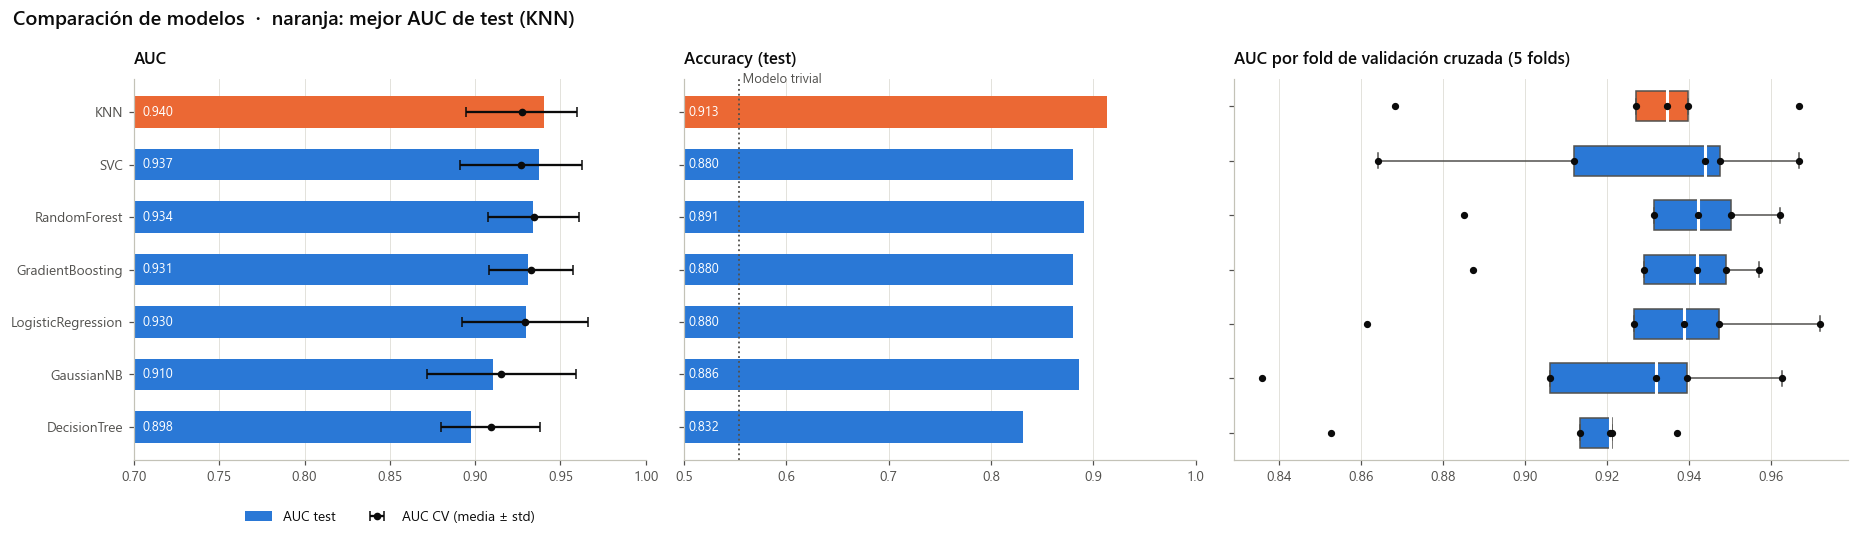

In [39]:
orden = ranking.index[::-1]
mejor = ranking.index[0]
colores = [COLOR["secundario"] if m == mejor else COLOR["principal"] for m in orden]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1, 1, 1.2]})

# Panel 1: AUC de test y AUC de CV (media ± desviación)
ax = axes[0]
ax.barh(orden, ranking.loc[orden, "AUC_test"], color=colores, height=0.6, label="AUC test")
ax.errorbar(ranking.loc[orden, "AUC_CV_media"], np.arange(len(orden)), xerr=ranking.loc[orden, "AUC_CV_std"],
            fmt="o", color=COLOR["texto"], markersize=4, capsize=3, label="AUC CV (media ± std)")
for i, v in enumerate(ranking.loc[orden, "AUC_test"]):
    ax.text(0.705, i, f"{v:.3f}", va="center", fontsize=8.5, color="white")
ax.set_xlim(0.7, 1)
ax.set_title("AUC")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)

# Panel 2: Accuracy de test
ax = axes[1]
ax.barh(orden, ranking.loc[orden, "Accuracy_test"], color=colores, height=0.6)
ax.axvline(y_test.mean(), color=COLOR["texto_2"], linestyle=":", linewidth=1.2)
ax.text(y_test.mean(), len(orden) - 0.45, " Modelo trivial", fontsize=8.5, color=COLOR["texto_2"])
for i, v in enumerate(ranking.loc[orden, "Accuracy_test"]):
    ax.text(0.505, i, f"{v:.3f}", va="center", fontsize=8.5, color="white")
ax.set_xlim(0.5, 1)
ax.set_yticklabels([])
ax.set_title("Accuracy (test)")

# Panel 3: AUC de cada fold de la validación cruzada
ax = axes[2]
datos_folds = [ranking.loc[m, "AUC_folds"] for m in orden]
cajas = ax.boxplot(datos_folds, vert=False, widths=0.55, patch_artist=True, showfliers=False,
                   medianprops=dict(color="white", linewidth=2),
                   whiskerprops=dict(color=COLOR["texto_2"]), capprops=dict(color=COLOR["texto_2"]))
for caja, c in zip(cajas["boxes"], colores):
    caja.set(facecolor=c, edgecolor=COLOR["texto_2"])
for i, valores in enumerate(datos_folds, start=1):
    ax.scatter(valores, np.full(len(valores), i), s=14, color=COLOR["texto"], zorder=3)
ax.set_yticks(np.arange(1, len(orden) + 1), [])
ax.set_title("AUC por fold de validación cruzada (5 folds)")

for ax in axes:
    ax.grid(axis="y", visible=False)
titulo_figura(fig, f"Comparación de modelos  ·  naranja: mejor AUC de test ({mejor})")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_comparacion_modelos.png")
plt.show()

Curvas ROC de todos los modelos en el conjunto de prueba

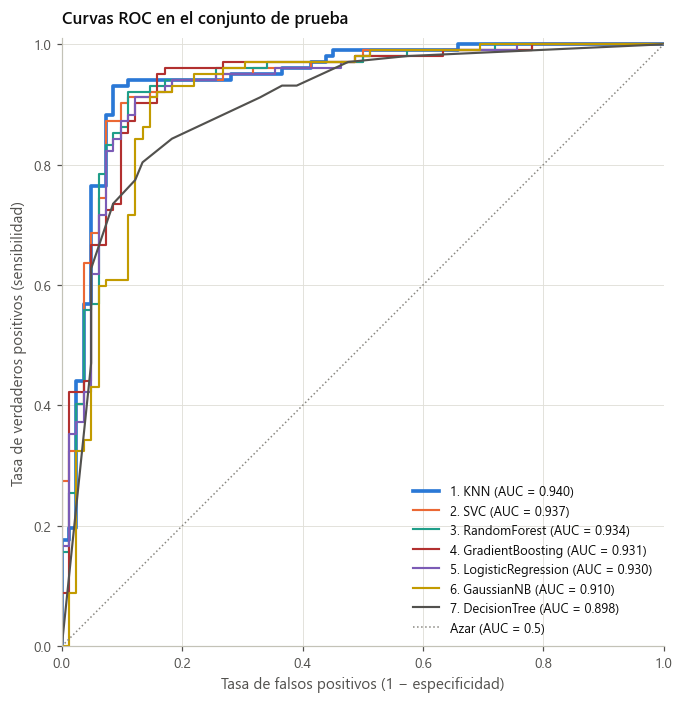

In [40]:
PALETA = ["#2a78d6", "#eb6834", "#1f9e89", "#b2302f", "#7b5bb6", "#c29b00", "#52514e"]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for (nombre, fila), color in zip(ranking.iterrows(), PALETA):
    fpr, tpr, _ = roc_curve(y_test, fila["proba_test"])
    ax.plot(fpr, tpr, color=color, linewidth=2.4 if nombre == mejor else 1.4,
            label=f"{fila['puesto']}. {nombre} (AUC = {fila['AUC_test']:.3f})")
ax.plot([0, 1], [0, 1], color=COLOR["tenue"], linestyle=":", linewidth=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("Curvas ROC en el conjunto de prueba")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_curvas_roc.png")
plt.show()

1. Barras y curvas ROC: las curvas ROC de los 5 mejores se superponen casi por completo. Solo el árbol de decisión y Naive Bayes se separan hacia abajo. El árbol tiene una curva con pocos escalones, porque con max_depth = 4 solo produce unas pocas probabilidades distintas.
2. Panel de folds: todos los modelos tienen un fold difícil, con AUC entre 0.84 y 0.89, y otros por encima de 0.93. Esa variación entre folds es mayor que la diferencia entre modelos, lo que confirma que el ranking de test no es concluyente entre los primeros puestos.

# Conclusiones de la Etapa 1

1. EDA: el dataset no tiene NaN explícitos, pero el 18.7 % de los valores de cholesterol son ceros imposibles y no faltan al azar. Se tratan con la mediana más un indicador de faltante, dentro del Pipeline.
2. Preprocesamiento: se usa un ColumnTransformer con imputación, MinMaxScaler y One-Hot. El split estratificado se hace antes de ajustar cualquier cosa.
3. Data leakage:
   1. La fuga del objetivo (leaky_feature) lleva el AUC a 1.000, y el Pipeline no la corrige: hay que detectarla revisando las variables.
   2. La fuga de preprocesamiento no cambia el resultado en este dataset (diferencia media −0.00005 en 50 repeticiones, p = 0.189), porque el escalado y la mediana son estadísticas estables.
   3. La fuga por selección de variables sí es grave: con ruido puro da AUC = 0.716 en lugar de 0.531.
   4. El Pipeline es la forma segura de evitar las dos últimas en cada fold de GridSearchCV.
4. Modelos: los 7 modelos superan ampliamente al modelo trivial. KNN (AUC = 0.940, Accuracy = 0.913), SVC, RandomForest, GradientBoosting y la regresión logística quedan empatados en la práctica, con AUC de test entre 0.930 y 0.940. El árbol de decisión es el más débil (0.898).
5. Para la Etapa 2: el modelo final no debe elegirse por el AUC de test. Si se usa test para escoger entre modelos, se introduce otra forma de fuga, porque test deja de ser una evaluación independiente. La elección se hará con el AUC de validación cruzada, donde RandomForest (0.934) y GradientBoosting (0.933) son los mejores. Test se usa una sola vez al final, para la matriz de confusión, la curva ROC y el AUC del notebook 2.